# Publications Classified: Implementation Notebook

This notebook implements the full classification pipeline described in the project design chapter. It takes computing research publications in PDF form and produces, for each one, the computing discipline, the field within that discipline, the research strategies used, the data generation methods, and the data analysis approach, together with confidence scores and the sentences from the paper that support each methodology decision.

The corpus is 300 arXiv computer science preprints stored locally in the dataset_raw folder. arXiv is openly licensed for text mining and attaches an author-selected subject category to every paper. That category is what makes the discipline and field labels verifiable, as explained in Section 5.

The notebook runs top to bottom. The slow steps (PDF extraction and SciBERT fine-tuning) cache their results, so re-running the notebook after the first pass takes a few minutes rather than the full extraction time.

| Section | Purpose | Research question |
|---|---|---|
| 1 | Setup and configuration | |
| 2 | Dataset verification (and download only if files are missing) | |
| 3 | Label taxonomy | |
| 4 | Layout-aware PDF ingestion | |
| 5 | Ground truth for discipline and field | |
| 6 | Structural segmentation | RQ1 |
| 7 | Context-aware methodology annotation | RQ1 |
| 8 | Data splits and human annotation of the test set | |
| 9 | Preprocessing and document views | |
| 10 | Discipline and field classifiers, model comparison | |
| 11 | Decoupled versus flat architectures | RQ2 |
| 12 | Which document zones carry the signal | RQ1, RQ3 |
| 13 | Methodology classifier | RQ1 |
| 14 | Interpretability | RQ3 |
| 15 | Multi-task SciBERT | RQ1, RQ2 |
| 16 | Held-out test evaluation and significance testing | |
| 17 | Final pipeline, JSON output and corpus analytics | |
| 18 | Evaluation summary | |

## 1. Setup

The core pipeline needs pdfplumber, scikit-learn, pandas, matplotlib and scipy. SciBERT in Section 15 also needs torch and transformers. If torch or transformers are missing, Section 15 is skipped and the rest of the notebook still runs. For GPU training, torch has to be the CUDA build, installed with the command from pytorch.org rather than a plain pip install.

In [1]:
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
from scipy.stats import binomtest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV, train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support, classification_report,
                             confusion_matrix, cohen_kappa_score, roc_auc_score, roc_curve)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

In [2]:
DATA_DIR = Path("dataset_raw")
TARGET_N_PAPERS = 300
CACHE_DIR = Path("cache")
EXTRACT_CACHE = CACHE_DIR / "extracted"
OUTPUT_DIR = Path("outputs")
MODEL_DIR = Path("models")
ANNOTATION_DIR = Path("annotation")
NEW_PAPERS_DIR = Path("new_papers")

for folder in [DATA_DIR, EXTRACT_CACHE, OUTPUT_DIR, MODEL_DIR, ANNOTATION_DIR, NEW_PAPERS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

#shared chart style
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8984"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True, "font.size": 9})

EVAL_ROWS = []


def record_result(section, task, model, split, metric, value, note=""):
    #collects every reported number for the summary table in section 18
    EVAL_ROWS.append({"section": section, "task": task, "model": model, "split": split,
                      "metric": metric, "value": round(float(value), 4), "note": note})


print("working directory:", Path.cwd())

working directory: C:\Users\user\Downloads\CM3070_Implementation_Notebook


## 2. Dataset Verification

The 300 PDFs were already downloaded into dataset_raw. This section checks that the folder holds 300 usable papers before anything else runs: every file must start with a valid PDF header, have a parseable arXiv identifier in its file name, and not duplicate another paper (two versions of the same preprint count once). The download code in the next section only runs if this check finds fewer than 300 usable papers, and then it only fetches the shortfall, so a complete folder never triggers any network calls.

In [3]:
ARXIV_FILE_PATTERN = re.compile(r"(\d{4}\.\d{4,5})(v\d+)?\.pdf$", re.IGNORECASE)


def inspect_raw_folder(folder):
    rows = []
    for path in sorted(folder.glob("*.pdf")):
        match = ARXIV_FILE_PATTERN.search(path.name)
        with open(path, "rb") as handle:
            header = handle.read(5)
        rows.append({"file": path.name,
                     "arxiv_id": match.group(1) if match else None,
                     "size_mb": round(path.stat().st_size / 1e6, 2),
                     "valid_pdf": header == b"%PDF-" and path.stat().st_size > 10_000})
    return pd.DataFrame(rows, columns=["file", "arxiv_id", "size_mb", "valid_pdf"])


raw_inventory = inspect_raw_folder(DATA_DIR)
usable = raw_inventory[raw_inventory["valid_pdf"] & raw_inventory["arxiv_id"].notna()]
duplicate_ids = usable[usable.duplicated("arxiv_id", keep=False)]
usable = usable.drop_duplicates("arxiv_id", keep="last")

print(f"pdf files found:        {len(raw_inventory)}")
print(f"invalid or unnamed:     {len(raw_inventory) - int((raw_inventory['valid_pdf'] & raw_inventory['arxiv_id'].notna()).sum())}")
print(f"duplicate versions:     {len(duplicate_ids)}")
print(f"usable unique papers:   {len(usable)} (target {TARGET_N_PAPERS})")

NEED_DOWNLOAD = len(usable) < TARGET_N_PAPERS
if NEED_DOWNLOAD:
    print(f"\nshort by {TARGET_N_PAPERS - len(usable)} papers, section 2.1 will fetch only the missing ones")
else:
    print("\ndataset complete, arXiv download will be skipped")
if len(raw_inventory) > len(usable):
    display(raw_inventory[~raw_inventory["file"].isin(usable["file"])])

pdf files found:        300
invalid or unnamed:     0
duplicate versions:     0
usable unique papers:   300 (target 300)

dataset complete, arXiv download will be skipped


### 2.1 Fetching Missing Papers From arXiv

This cell is skipped when the check above passes. If it does run, it pages through the arXiv API for recent computer science submissions, skips papers already on disk, and downloads PDFs until the folder reaches the target. It waits 3 seconds between requests, as arXiv's API terms ask, and backs off on HTTP 429 responses.

In [4]:
import urllib.request
import urllib.parse
import urllib.error
import xml.etree.ElementTree as ET

ARXIV_API = "https://export.arxiv.org/api/query"
ATOM = {"atom": "http://www.w3.org/2005/Atom"}
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; CM3070-student-project)",
           "Accept": "application/atom+xml, application/xml, text/html;q=0.9, */*;q=0.8"}


def http_get(url, retries=4, delay=3.0):
    for attempt in range(1, retries + 1):
        try:
            with urllib.request.urlopen(urllib.request.Request(url, headers=HEADERS), timeout=60) as response:
                return response.read()
        except urllib.error.HTTPError as error:
            if 400 <= error.code < 500 and error.code != 429:
                print(f"  http {error.code} for {url}, not retrying")
                return None
            wait = 20 * attempt if error.code == 429 else delay * attempt
            print(f"  http {error.code}, retry {attempt}/{retries} in {wait:.0f}s")
            time.sleep(wait)
        except Exception as error:
            print(f"  {error}, retry {attempt}/{retries}")
            time.sleep(delay * attempt)
    return None


def fetch_missing_papers(n_needed, existing_ids, page_size=100, delay=3.0):
    downloaded, start = 0, 0
    while downloaded < n_needed and start < 5000:
        query = urllib.parse.urlencode({"search_query": "cat:cs.*", "start": start, "max_results": page_size,
                                        "sortBy": "submittedDate", "sortOrder": "descending"})
        feed = http_get(f"{ARXIV_API}?{query}")
        time.sleep(delay)
        if feed is None:
            break
        entries = ET.fromstring(feed).findall("atom:entry", ATOM)
        if not entries:
            break
        for entry in entries:
            versioned_id = entry.find("atom:id", ATOM).text.rsplit("/", 1)[-1]
            base_id = re.sub(r"v\d+$", "", versioned_id)
            if base_id in existing_ids:
                continue
            pdf_bytes = http_get(f"https://arxiv.org/pdf/{versioned_id}")
            time.sleep(delay)
            if pdf_bytes and pdf_bytes[:5] == b"%PDF-":
                (DATA_DIR / f"arxiv_{versioned_id}.pdf").write_bytes(pdf_bytes)
                existing_ids.add(base_id)
                downloaded += 1
                print(f"  [{downloaded}/{n_needed}] {versioned_id}")
            if downloaded >= n_needed:
                break
        start += page_size
    return downloaded


if NEED_DOWNLOAD:
    n_new = fetch_missing_papers(TARGET_N_PAPERS - len(usable), set(usable["arxiv_id"]))
    print(f"downloaded {n_new} papers")
    raw_inventory = inspect_raw_folder(DATA_DIR)
    usable = raw_inventory[raw_inventory["valid_pdf"] & raw_inventory["arxiv_id"].notna()].drop_duplicates("arxiv_id", keep="last")
else:
    print("skipped: dataset_raw already holds the full corpus")

PAPER_FILES = [DATA_DIR / name for name in usable["file"]]
print(f"papers entering the pipeline: {len(PAPER_FILES)}")

skipped: dataset_raw already holds the full corpus
papers entering the pipeline: 300


## 3. Label Taxonomy

The classification has three tiers, following the hierarchy set out in the literature review (Pilkington and Pretorius, 2015): discipline, then field within the discipline, then the research methodology.

### 3.1 Disciplines and Fields

Disciplines follow the ACM and IEEE Computing Curricula 2020 report (CC2020), which recognises Computer Science, Software Engineering, Information Systems, Information Technology and Computer Engineering as separate computing disciplines. Each field groups one or more arXiv subject categories, and each field belongs to exactly one discipline, so a paper's arXiv category determines both its discipline and its field. Categories outside computer science fall back on their archive (stat to machine learning, math to theory, Electrical Equipment to hardware and systems). Anything else is mapped to Other.

In [5]:
TAXONOMY = {
    "Computer Science": {
        "Artificial Intelligence and Machine Learning": ["cs.AI", "cs.LG", "cs.NE", "cs.MA", "stat.ML"],
        "Computer Vision, Graphics and Multimedia": ["cs.CV", "cs.GR", "cs.MM", "cs.SD", "eess.IV", "eess.AS"],
        "Natural Language Processing": ["cs.CL"],
        "Robotics": ["cs.RO"],
        "Theory and Algorithms": ["cs.DS", "cs.CC", "cs.LO", "cs.FL", "cs.CG", "cs.DM", "cs.GT", "cs.SC",
                                  "cs.IT", "cs.NA", "cs.MS", "cs.CE"],
    },
    "Software Engineering": {
        "Software Engineering and Programming Languages": ["cs.SE", "cs.PL"],
    },
    "Information Systems": {
        "Human-Computer Interaction": ["cs.HC"],
        "Information Retrieval and Data Management": ["cs.IR", "cs.DB", "cs.DL"],
        "Computing and Society": ["cs.CY", "cs.SI"],
    },
    "Information Technology": {
        "Networking and Distributed Systems": ["cs.NI", "cs.DC", "cs.OS", "cs.PF"],
        "Cybersecurity": ["cs.CR"],
    },
    "Computer Engineering": {
        "Hardware and Systems": ["cs.AR", "cs.ET", "cs.SY", "eess.SY", "eess.SP"],
    },
}
ARCHIVE_FALLBACK = {"stat": "Artificial Intelligence and Machine Learning", "math": "Theory and Algorithms",
                    "eess": "Hardware and Systems"}

CATEGORY_TO_FIELD = {cat: field for fields in TAXONOMY.values() for field, cats in fields.items() for cat in cats}
FIELD_TO_DISCIPLINE = {field: disc for disc, fields in TAXONOMY.items() for field in fields}
FIELD_TO_DISCIPLINE["Other"] = "Other"


def category_to_labels(category):
    if not category:
        return "Other", "Other"
    field = CATEGORY_TO_FIELD.get(category) or ARCHIVE_FALLBACK.get(category.split(".")[0], "Other")
    return FIELD_TO_DISCIPLINE[field], field


print(f"{len(TAXONOMY)} disciplines, {len(FIELD_TO_DISCIPLINE) - 1} fields, {len(CATEGORY_TO_FIELD)} arXiv categories mapped")

5 disciplines, 12 fields, 43 arXiv categories mapped


### 3.2 Research Methodology

The methodology tier follows Oates (2006), who describes a piece of research by its strategy, the methods used to generate data, and how the data is analysed. Oates names six strategies: survey, design and creation, experiment, case study, action research and ethnography. Studies of computing research have also found three more that are common in the field: formal or mathematical proof, simulation, and literature review (Glass, Ramesh and Vessey, 2004). All nine are used here. A paper can use more than one strategy, so this tier is multi-label. Data generation methods and the analysis approach come from the same source and are extracted as supporting detail.

In [6]:
STRATEGIES = ["Design and Creation", "Experiment", "Survey", "Case Study", "Action Research",
              "Ethnography", "Formal Proof", "Simulation", "Literature Review"]
DATA_GENERATION = ["Interviews", "Questionnaires", "Observation", "Documents", "Datasets and Benchmarks"]

STRATEGY_DEFINITIONS = {
    "Design and Creation": "develops a new IT artefact (system, model, method, algorithm or tool) as a main contribution",
    "Experiment": "tests cause and effect or compares conditions or systems under controlled measurement",
    "Survey": "collects standardised data from a sample of a wider population, usually by questionnaire",
    "Case Study": "investigates one instance (organisation, project, system) in depth in its real-life context",
    "Action Research": "researchers work with practitioners through cycles of planning, acting and reflecting",
    "Ethnography": "the researcher spends extended time in the field observing a community or culture",
    "Formal Proof": "establishes properties through mathematical theorems and proofs",
    "Simulation": "studies behaviour through a computational model of a system run under varied conditions",
    "Literature Review": "systematically collects and synthesises published studies as the main contribution",
}
pd.DataFrame({"strategy": STRATEGIES, "definition": [STRATEGY_DEFINITIONS[s] for s in STRATEGIES]})

,strategy,definition
0,Design and Creation,"develops a new IT artefact (system, model, method, algorithm or tool) as a main contribution"
1,Experiment,tests cause and effect or compares conditions or systems under controlled measurement
2,Survey,"collects standardised data from a sample of a wider population, usually by questionnaire"
3,Case Study,"investigates one instance (organisation, project, system) in depth in its real-life context"
4,Action Research,"researchers work with practitioners through cycles of planning, acting and reflecting"
5,Ethnography,the researcher spends extended time in the field observing a community or culture
6,Formal Proof,establishes properties through mathematical theorems and proofs
7,Simulation,studies behaviour through a computational model of a system run under varied conditions
8,Literature Review,systematically collects and synthesises published studies as the main contribution


## 4. Layout-Aware PDF Ingestion

Most computing papers use a two-column layout. A plain text dump reads straight across the page, so lines from the left and right columns get interleaved and sentences are scrambled. The extractor works from word coordinates instead. For every page it looks for a vertical gutter near the centre that almost no words cross. If a gutter is found, the page is read left column first, then right column. Lines that span the gutter (titles, full-width figures, captions) are emitted in their vertical position and split the page into bands, so a full-width abstract above two columns is still read in the correct order.

Word gaps are detected with a tight horizontal tolerance (1.5 points instead of pdfplumber's default 3). With the default, the narrow spacing in the ACM and AAAI templates merged whole phrases into one token. Words are grouped into lines by their baseline rather than their top edge, so small-capital headings such as "II. RELATED WORK" in the IEEE template stay on one line. Glyph placeholders such as "(cid:98)", which appear when a font has no text mapping, are removed. Each line keeps its font size and whether it is bold, because Section 6 uses both to find section headings. On the first page, the rotated text in the left margin is read separately, since that is where arXiv prints the paper's identifier and primary subject category.

In [7]:
STAMP_PATTERN = re.compile(r"arXiv:\s*(\d{4}\.\d{4,5})(v\d+)?\s*\[([A-Za-z\-]+(?:\.[A-Za-z\-]+)?)\]")
BOLD_FONT = re.compile(r"bold|black|heavy|semibold|demi|medi|[-+,.]b$|tb$|bd$|cmbx", re.IGNORECASE)
CID_GLYPH = re.compile(r"\(cid:\d+\)")
EXTRACTOR_VERSION = 2


def group_rows(words, tolerance=3.0):
    #rows are grouped on the text baseline so small caps stay on the same line as their capitals
    rows, current, current_bottom = [], [], None
    for word in sorted(words, key=lambda w: (round(w["bottom"]), w["x0"])):
        if current and abs(word["bottom"] - current_bottom) > tolerance:
            rows.append(current)
            current = []
        if not current:
            current_bottom = word["bottom"]
        current.append(word)
    if current:
        rows.append(current)
    return rows


def to_line(words):
    words = sorted(words, key=lambda w: w["x0"])
    n_bold = sum(bool(BOLD_FONT.search(w.get("fontname", ""))) for w in words)
    text = CID_GLYPH.sub("", " ".join(w["text"] for w in words))
    return {"text": re.sub(r"\s+", " ", text).strip(), "size": round(max(w["size"] for w in words), 1),
            "bold": n_bold > len(words) / 2}


def find_gutter(words, width):
    candidates = [width * pct / 100 for pct in range(38, 63)]
    crossings = [sum(1 for w in words if w["x0"] < x < w["x1"]) for x in candidates]
    best = min(range(len(candidates)), key=lambda i: (crossings[i], abs(candidates[i] - width / 2)))
    gutter = candidates[best]
    left = sum(1 for w in words if w["x1"] <= gutter)
    right = sum(1 for w in words if w["x0"] >= gutter)
    is_two_column = crossings[best] <= max(3, 0.04 * len(words)) and min(left, right) > 0.2 * len(words)
    return gutter if is_two_column else None


def extract_page_lines(page):
    words = [w for w in page.extract_words(x_tolerance=1.5, y_tolerance=3, extra_attrs=["size", "fontname", "upright"])
             if w["upright"]]
    if not words:
        return [], False
    gutter = find_gutter(words, float(page.width))
    rows = group_rows(words)
    if gutter is None:
        return [to_line(r) for r in rows], False

    lines, left_band, right_band = [], [], []
    for row in rows:
        if any(w["x0"] < gutter < w["x1"] for w in row):
            lines.extend(left_band + right_band)
            left_band, right_band = [], []
            lines.append(to_line(row))
            continue
        left_words = [w for w in row if w["x1"] <= gutter]
        right_words = [w for w in row if w["x0"] >= gutter]
        if left_words:
            left_band.append(to_line(left_words))
        if right_words:
            right_band.append(to_line(right_words))
    lines.extend(left_band + right_band)
    return lines, True


def read_arxiv_stamp(page):
    rotated = [c for c in page.chars if not c.get("upright", True)]
    #rotated figure labels can share the page with the stamp, so each vertical text column is read on its own
    columns = defaultdict(list)
    for c in rotated:
        columns[round(c["x0"] / 4)].append(c)
    for chars in list(columns.values()) + [rotated]:
        match = STAMP_PATTERN.search("".join(c["text"] for c in sorted(chars, key=lambda c: -c["top"])))
        if match:
            return {"arxiv_id": match.group(1), "category": match.group(3)}
    match = STAMP_PATTERN.search(page.extract_text() or "")
    return {"arxiv_id": match.group(1), "category": match.group(3)} if match else None

The design chapter's contingency plan sends pages with almost no extractable text to optical character recognition (pytesseract). arXiv PDFs are generated from LaTeX, so this should rarely happen. pytesseract also needs the separate Tesseract program installed, so if it is unavailable the paper is flagged rather than stopping the run. Results are cached as one JSON file per paper, which means the full extraction only runs once. Each cached file records the extractor version, and files written by an older version are extracted again automatically.

In [8]:
MAX_PAGES = 40
MIN_WORDS_BEFORE_OCR = 300

try:
    import pytesseract
    pytesseract.get_tesseract_version()
    OCR_AVAILABLE = True
except Exception:
    OCR_AVAILABLE = False


def ocr_pages(pdf):
    lines = []
    for page_number, page in enumerate(pdf.pages[:MAX_PAGES]):
        text = pytesseract.image_to_string(page.to_image(resolution=200).original)
        lines.extend({"page": page_number, "text": t, "size": 0.0, "bold": False} for t in text.splitlines() if t.strip())
    return lines


def extract_pdf(path):
    cache_file = EXTRACT_CACHE / f"{path.stem}.json"
    if cache_file.exists():
        cached = json.loads(cache_file.read_text(encoding="utf-8"))
        if cached.get("version") == EXTRACTOR_VERSION:
            return cached

    record = {"version": EXTRACTOR_VERSION, "file": path.name, "stamp": None, "n_pages": 0, "two_column_pages": 0, "lines": [], "ocr": "not_needed"}
    try:
        with pdfplumber.open(path) as pdf:
            record["n_pages"] = len(pdf.pages)
            for page_number, page in enumerate(pdf.pages[:MAX_PAGES]):
                if page_number == 0:
                    record["stamp"] = read_arxiv_stamp(page)
                page_lines, two_column = extract_page_lines(page)
                record["two_column_pages"] += int(two_column)
                record["lines"].extend({"page": page_number, **line} for line in page_lines)
            n_words = sum(len(line["text"].split()) for line in record["lines"])
            if n_words < MIN_WORDS_BEFORE_OCR:
                if OCR_AVAILABLE:
                    record["lines"] = ocr_pages(pdf)
                    record["ocr"] = "applied"
                else:
                    record["ocr"] = "needed_but_unavailable"
    except Exception as error:
        record["error"] = str(error)

    cache_file.write_text(json.dumps(record), encoding="utf-8")
    return record

In [9]:
start = time.time()
extracted = {}
for i, path in enumerate(PAPER_FILES, 1):
    extracted[path.stem] = extract_pdf(path)
    if i % 25 == 0 or i == len(PAPER_FILES):
        print(f"  {i}/{len(PAPER_FILES)} papers, {time.time() - start:.0f}s elapsed")

extraction_stats = pd.DataFrame([{
    "doc": doc_id,
    "pages": rec["n_pages"],
    "two_column_share": rec["two_column_pages"] / max(1, min(rec["n_pages"], MAX_PAGES)),
    "words": sum(len(line["text"].split()) for line in rec["lines"]),
    "stamp_found": rec["stamp"] is not None,
    "ocr": rec["ocr"],
    "error": rec.get("error", ""),
} for doc_id, rec in extracted.items()])

print(f"\nmean pages {extraction_stats['pages'].mean():.1f}, mean words {extraction_stats['words'].mean():.0f}")
print(f"papers with a two-column layout: {(extraction_stats['two_column_share'] > 0.5).sum()}")
print(f"arXiv stamp found: {extraction_stats['stamp_found'].sum()}/{len(extraction_stats)}")
print("ocr status:", dict(Counter(extraction_stats["ocr"])))
print(f"extraction errors: {(extraction_stats['error'] != '').sum()}")

  25/300 papers, 0s elapsed
  50/300 papers, 0s elapsed
  75/300 papers, 0s elapsed
  100/300 papers, 0s elapsed
  125/300 papers, 0s elapsed
  150/300 papers, 0s elapsed
  175/300 papers, 0s elapsed
  200/300 papers, 0s elapsed
  225/300 papers, 0s elapsed
  250/300 papers, 1s elapsed
  275/300 papers, 1s elapsed
  300/300 papers, 1s elapsed

mean pages 21.4, mean words 11080
papers with a two-column layout: 180
arXiv stamp found: 281/300
ocr status: {'not_needed': 300}
extraction errors: 0


The excerpt below is from a two-column paper, printed in the order the extractor reads it. Lines should run as complete sentences, not jump between columns.

In [10]:
two_column_docs = extraction_stats.sort_values("two_column_share", ascending=False)["doc"].tolist()
example_doc = two_column_docs[0]
example_lines = [line["text"] for line in extracted[example_doc]["lines"] if line["page"] == 0]
print(example_doc)
print("\n".join(example_lines[8:26]))

arxiv_2608.12025v1
Kaiserslautern, Germany rasmus.adler@iese.fraunhofer.de Kaiserslautern, Germany
tuhinangshu.gangopadhyay@iese-extern.fraunhofer.de
peter.liggesmeyer@iese.fraunhofer.de
Jan Reich
Fraunhofer IESE
Kaiserslautern, Germany
jan.reich@iese.fraunhofer.de
Abstract —Medical devices are becoming more software-
intensive, connected, and AI-enabled. Their development requires
risk-management evidence aligned with ISO 14971 and, for
software, IEC 62304. This evidence must be kept consistent across
requirements, design decisions, software changes, verification
results, complaints, and post-market data. These tasks are costly
and depend on scarce safety and domain experts.
Large language models (LLMs) may reduce parts of this
effort because medical-device safety work is highly document-
based. However, current LLM-based safety-engineering studies
often address isolated methods, rely on generic prompting or


## 5. Ground Truth for Discipline and Field

The discipline and field labels are not guessed from the text. They come from the primary subject category the authors chose when submitting to arXiv, which arXiv's moderators check. That category is independent of the classifier's input, so it is a fair target to evaluate against, and it removes the need to hand-label these two tiers.

The category is read from the stamp arXiv prints in the margin of each PDF. Some submissions are distributed without that stamp, so for those papers the category is looked up online, first through the arXiv API and then, if that fails, from the paper's arXiv abstract page. Results are cached, so each paper is looked up only once. If a lookup still fails (for example without internet access), the paper is listed in manual_categories.csv, where its category can be typed in by hand from the paper's arXiv page. Categories in that file take priority on the next run.

In [11]:
METADATA_CACHE = CACHE_DIR / "arxiv_metadata.json"
MANUAL_CATEGORIES = Path("manual_categories.csv")
PRIMARY_SUBJECT = re.compile(r'primary-subject">[^<(]*\(([A-Za-z\-]+(?:\.[A-Za-z\-]+)?)\)')
metadata = json.loads(METADATA_CACHE.read_text()) if METADATA_CACHE.exists() else {}
manual = {}
if MANUAL_CATEGORIES.exists():
    manual_sheet = pd.read_csv(MANUAL_CATEGORIES, dtype=str).fillna("")
    manual = {r["arxiv_id"]: r["category"].strip() for _, r in manual_sheet.iterrows() if r["category"].strip()}


def base_id(record):
    return ARXIV_FILE_PATTERN.search(record["file"]).group(1)


def lookup_categories(ids):
    found = {}
    for start in range(0, len(ids), 50):
        feed = http_get(f"{ARXIV_API}?" + urllib.parse.urlencode({"id_list": ",".join(ids[start:start + 50]), "max_results": 50}))
        if feed:
            for entry in ET.fromstring(feed).findall("atom:entry", ATOM):
                primary = entry.find("{http://arxiv.org/schemas/atom}primary_category")
                if primary is not None:
                    found[re.sub(r"v\d+$", "", entry.find("atom:id", ATOM).text.rsplit("/", 1)[-1])] = primary.get("term")
        time.sleep(3)
    for arxiv_id in [i for i in ids if i not in found]:
        page = http_get(f"https://arxiv.org/abs/{arxiv_id}", retries=2)
        match = PRIMARY_SUBJECT.search(page.decode("utf-8", "ignore")) if page else None
        if match:
            found[arxiv_id] = match.group(1)
        time.sleep(3)
    return found


unstamped = [base_id(rec) for rec in extracted.values() if rec["stamp"] is None]
to_lookup = [i for i in unstamped if i not in metadata and i not in manual]
if to_lookup:
    metadata.update(lookup_categories(to_lookup))
    METADATA_CACHE.write_text(json.dumps(metadata))
unresolved = [i for i in unstamped if i not in metadata and i not in manual]
print(f"papers without a stamp: {len(unstamped)}, resolved online or from cache: "
      f"{sum(i in metadata for i in unstamped)}, entered by hand: {sum(i in manual for i in unstamped)}")
if unresolved:
    rows = [{"arxiv_id": i, "category": c} for i, c in manual.items()] + [{"arxiv_id": i, "category": ""} for i in unresolved]
    pd.DataFrame(rows).to_csv(MANUAL_CATEGORIES, index=False)
    print(f"{len(unresolved)} papers still have no category and are labelled Other for now; "
          f"fill in {MANUAL_CATEGORIES} and re-run this cell")

papers = []
for doc_id, rec in extracted.items():
    arxiv_id = base_id(rec)
    category = rec["stamp"]["category"] if rec["stamp"] else manual.get(arxiv_id) or metadata.get(arxiv_id)
    discipline, field = category_to_labels(category)
    papers.append({"doc": doc_id, "arxiv_id": arxiv_id, "category": category, "discipline": discipline, "field": field})
papers = pd.DataFrame(papers).set_index("doc")
papers["category"].value_counts().head(15)

papers without a stamp: 19, resolved online or from cache: 19, entered by hand: 0


category
cs.SE       76
cs.LG       64
cs.AI       54
cs.HC       26
cs.CR       15
cs.CV       13
cs.CL       10
stat.ML      8
cs.RO        6
eess.IV      2
cs.CY        2
cs.IR        2
q-bio.QM     2
cs.CE        2
cs.MA        2
Name: count, dtype: int64

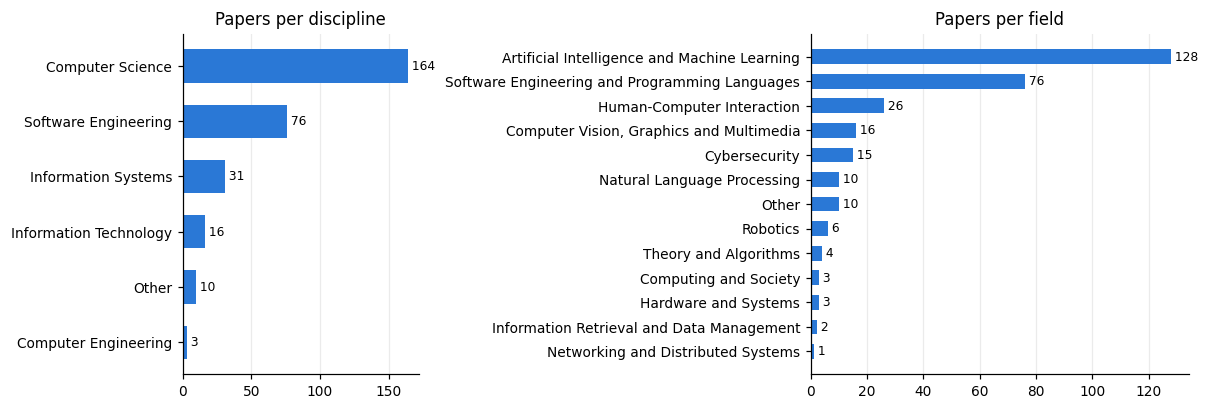

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1, 1.6]})
disc_counts = papers["discipline"].value_counts()
axes[0].barh(disc_counts.index[::-1], disc_counts.values[::-1], color=BLUE, height=0.6)
axes[0].set_title("Papers per discipline")
field_counts = papers["field"].value_counts()
axes[1].barh(field_counts.index[::-1], field_counts.values[::-1], color=BLUE, height=0.6)
axes[1].set_title("Papers per field")
for ax, counts in [(axes[0], disc_counts), (axes[1], field_counts)]:
    ax.grid(axis="y", visible=False)
    for y, v in enumerate(counts.values[::-1]):
        ax.text(v, y, f" {v}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution.png", bbox_inches="tight")
plt.show()

arXiv's computer science listings are dominated by machine learning, vision and language papers, so the classes are imbalanced. For this reason, macro-averaged F1, which weights every class equally, is the headline metric throughout. All linear models use balanced class weights (the design chapter's plan for class imbalance), and SciBERT uses weighted loss functions.

## 6. Structural Segmentation

The report's first research question depends on telling apart sections where a paper applies a method from sections where it only discusses other work. The segmenter turns the ordered line stream into named zones: front matter, abstract, introduction, related work, method, evaluation, discussion, conclusion, references and appendix.

A line is treated as a top-level heading when it matches one of three forms. The first is a numbered heading ("3 System Design", "IV. EVALUATION", "2 | RELATED WORK") that is visually distinct from body text (a larger font, bold, or mostly capitals) and continues the numbering sequence, which rules out running headers and numbered list items. Roman-numeral headings in title case ("II. Proposed Approach") are accepted even at body size, since that numbering is distinctive on its own. Numbered author affiliations ("1 Department of Computing, ...") are skipped, and "1 Introduction" restarts the sequence if front matter has already used the numbers. The second form is a short unnumbered line whose text names a standard section and is set like the paper's other top-level headings. The third is an unnumbered line set in the same style (font size and weight) as those confirmed headings, which catches templates like AAAI where headings are unnumbered.

Headings that match no known section name, such as "3 PolyDebate", open a generic body zone, which is treated as part of the paper's own contribution. Abstracts are found from an "Abstract" heading or from a paragraph that starts with the word. Templates without either put the abstract between the author block and the keywords, so the text just before the keywords is used. If no structure is found at all, the fallback from the design chapter applies: the first 2,000 words after the abstract are used as the method zone.

In [13]:
ZONE_KEYWORDS = [
    ("abstract", r"abstract"),
    ("introduction", r"introduction|overview|motivation"),
    ("related_work", r"related work|background|literature review|prior work|previous work|state of the art|preliminaries"),
    ("references", r"references|bibliography|works cited"),
    ("appendix", r"appendix|appendices|supplementary"),
    ("keywords", r"ccs concepts|keywords|index terms|acm reference format"),
    ("acknowledgements", r"acknowledge?ments?|funding|generative ai usage|ethics statement|author contributions"),
    ("conclusion", r"conclusions?|concluding remarks|summary"),
    ("discussion", r"discussion|limitations|threats to validity|implications|future work|broader impact"),
    ("evaluation", r"experiments?|experimental|evaluation|results|findings|user study|case stud|performance|validation|empirical|analysis"),
    ("method", r"method|methodology|research design|study design|approach|proposed|framework|system|design|implementation|model|architecture|problem|data|participants|procedure|setup|materials"),
]
ZONE_PATTERNS = [(zone, re.compile(rf"^(?:{pattern})", re.IGNORECASE)) for zone, pattern in ZONE_KEYWORDS]
NUMBERED_HEADING = re.compile(r"^(?P<num>\d{1,2}|[IVX]{1,5})(?:\.|\s*\|)?\s+(?P<title>[A-Z][^.]{1,90})$")
AFFILIATION = re.compile(r"\b(?:universit\w*|institut\w*|department|college|school of|laborator\w*|inc|llc|corporation|academy)\b", re.IGNORECASE)
FRONT_MATTER_END = re.compile(r"CCS Concepts|Additional Key Words|ACM Reference Format|Keywords|Index Terms|K\s?EYWORDS")
ROMAN = {"I": 1, "II": 2, "III": 3, "IV": 4, "V": 5, "VI": 6, "VII": 7, "VIII": 8, "IX": 9, "X": 10, "XI": 11, "XII": 12}
APPENDIX_HEADING = re.compile(r"^[A-H](?:\.\d)?\s+[A-Z][A-Za-z]")
INLINE_ABSTRACT = re.compile(r"^a\s?bstract\b\s*[\u2014\u2013:.\-]?\s*", re.IGNORECASE)
EXCLUDED_ZONES = {"front", "keywords", "related_work", "references", "acknowledgements"}
CORE_ZONES = {"method", "evaluation", "body"}


def normalise_heading(text):
    #joins small caps split by the extractor, e.g. "I NTRODUCTION"
    return re.sub(r"\b([A-Z]) ([A-Z]{2,})", r"\1\2", text).strip()


def zone_for_title(title):
    title = re.sub(r"^[\W\d]+", "", title).strip()
    for zone, pattern in ZONE_PATTERNS:
        if pattern.match(title):
            return zone
    return None


def upper_ratio(text):
    letters = [c for c in text if c.isalpha()]
    return sum(c.isupper() for c in letters) / max(1, len(letters))


def is_title_case(text):
    words = [w for w in text.split() if len(w) > 3 and w[0].isalpha()]
    return bool(words) and all(w[0].isupper() for w in words)


def join_lines(lines):
    text = ""
    for line in lines:
        if text.endswith("-") and line[:1].islower():
            text = text[:-1] + line
        else:
            text = f"{text} {line}" if text else line
    return re.sub(r"\s+", " ", text).strip()

In [14]:
def detect_headings(lines):
    sizes = [line["size"] for line in lines if len(line["text"].split()) > 6]
    body_size = float(np.median(sizes)) if sizes else 10.0
    headings, unnumbered, numbered = {}, {}, []
    last_number, numbering = 0, None

    for i, line in enumerate(lines):
        text = normalise_heading(line["text"])
        n_words = len(text.split())
        distinct = line["size"] >= body_size + 0.3 or line["bold"] or upper_ratio(text) > 0.7
        match = NUMBERED_HEADING.match(text)
        if n_words > 12 or AFFILIATION.search(text):
            continue
        if match:
            num, title = match.group("num"), match.group("title")
            if not (num in ROMAN or num.isdigit()):
                continue
            style = "roman" if num in ROMAN else "arabic"
            value = ROMAN[num] if style == "roman" else int(num)
            #roman numerals are distinctive enough in title case even at body size and weight
            if not (distinct or (style == "roman" and is_title_case(title))) or not re.search(r"[A-Za-z]{3,}", title):
                continue
            if value == 1 and zone_for_title(title) == "introduction" and last_number > 0:
                #"1 Introduction" restarts a sequence begun by numbered front matter
                for j in numbered:
                    headings.pop(j, None)
                numbered, last_number, numbering = [], 0, None
            if value == last_number + 1 and numbering in {style, None}:
                headings[i] = zone_for_title(title) or "body"
                numbered.append(i)
                last_number, numbering = value, style
            continue
        if not distinct:
            continue
        previous = lines[i - 1] if i else None
        continues_heading = (previous is not None and previous["size"] == line["size"] and previous["bold"] == line["bold"]
                             and len(previous["text"].split()) <= 12 and not previous["text"].endswith("."))
        zone = zone_for_title(text)
        if zone and n_words <= 4 and not continues_heading and re.fullmatch(r"[A-Za-z][A-Za-z ,&:\-]+", text):
            unnumbered[i] = zone

    #unnumbered keyword headings must match the size of top-level ones such as introduction or references
    anchors = [lines[i] for i, z in unnumbered.items() if z in {"introduction", "references", "conclusion"}]
    min_size = max(a["size"] for a in anchors) - 0.1 if anchors else 0
    for i, zone in unnumbered.items():
        if lines[i]["size"] >= min_size or zone == "abstract":
            headings[i] = zone

    #in unnumbered templates, other lines styled like the confirmed headings are headings too
    if anchors and last_number == 0:
        style = Counter((a["size"], a["bold"]) for a in anchors).most_common(1)[0][0]
        if style[1] or style[0] > body_size + 0.8:
            seen_start = False
            for i, line in enumerate(lines):
                seen_start = seen_start or headings.get(i) in {"abstract", "introduction"}
                text = line["text"].strip()
                previous = lines[i - 1] if i else None
                continues_heading = previous is not None and (previous["size"], previous["bold"]) == style and i - 1 in headings
                if (seen_start and i not in headings and (line["size"], line["bold"]) == style and not continues_heading
                        and len(text.split()) <= 8 and not text.endswith(".") and re.match(r"[A-Z]", text)):
                    headings[i] = zone_for_title(text) or "body"
    return headings, body_size


def segment_document(record):
    lines = record["lines"]
    headings, body_size = detect_headings(lines)
    zones, current = defaultdict(list), "front"
    heading_log = []
    for i, line in enumerate(lines):
        text = line["text"]
        if current in {"references", "appendix"}:
            #only an appendix can follow the references
            starts_appendix = headings.get(i) == "appendix" or (APPENDIX_HEADING.match(text) and line["size"] > body_size)
            if current == "references" and starts_appendix:
                current = "appendix"
                heading_log.append(("appendix", text))
                continue
            zones[current].append(text)
            continue
        if i in headings:
            current = headings[i]
            heading_log.append((current, normalise_heading(text)))
            continue
        if current in {"front", "introduction"} and len(text.split()) > 3 and INLINE_ABSTRACT.match(normalise_heading(text)):
            current = "abstract"
            heading_log.append(("abstract", "Abstract (inline)"))
            text = INLINE_ABSTRACT.sub("", normalise_heading(text))
        zones[current].append(text)

    zone_text = {zone: join_lines(z_lines) for zone, z_lines in zones.items()}
    title_lines = [l for l in lines[:25] if l["page"] == 0]
    title = ""
    if title_lines:
        top_size = max(l["size"] for l in title_lines)
        title = join_lines([l["text"] for l in title_lines if l["size"] == top_size][:3])

    method = "headings"
    if not any(zone_text.get(z) for z in CORE_ZONES):
        body_words = " ".join(zone_text.get(z, "") for z in ["introduction", "front"]).split()
        zone_text["body"] = " ".join(body_words[:2000])
        method = "fallback_window"
    if not zone_text.get("abstract"):
        #templates without an abstract heading put it after the authors and before the keywords block
        front = FRONT_MATTER_END.split(zone_text.get("front", ""))[0]
        zone_text["abstract"] = " ".join(front.split()[-300:])
        method += "+abstract_fallback"
    return {"title": title, "zones": zone_text, "headings": heading_log, "method": method}

In [15]:
segments = {doc_id: segment_document(rec) for doc_id, rec in extracted.items()}

zone_presence = pd.DataFrame([{zone: bool(seg["zones"].get(zone)) for zone in
                               ["abstract", "introduction", "related_work", "method", "evaluation", "body",
                                "discussion", "conclusion", "references", "appendix"]}
                              for seg in segments.values()], index=list(segments))
print("share of papers in which each zone was found:")
print(zone_presence.mean().round(2).to_string())
print("\nsegmentation method:", dict(Counter(seg["method"] for seg in segments.values())))
papers["title"] = [segments[d]["title"] for d in papers.index]

share of papers in which each zone was found:
abstract        1.00
introduction    0.96
related_work    0.72
method          0.60
evaluation      0.73
body            0.70
discussion      0.53
conclusion      0.80
references      0.93
appendix        0.34

segmentation method: {'headings': 268, 'headings+abstract_fallback': 24, 'fallback_window': 5, 'fallback_window+abstract_fallback': 3}


In [16]:
for doc_id in list(segments)[:2]:
    print(f"{doc_id}: {segments[doc_id]['title'][:90]}")
    for zone, heading in segments[doc_id]["headings"]:
        print(f"    {zone:<16} {heading[:70]}")
    print()

arxiv_2608.12025v1: From Safety Documentation to Safety Knowledge Support: An Evidence-Grounded LLM Framework 
    abstract         Abstract (inline)
    introduction     I. INTRODUCTION
    body             II. MEDICAL -DEVICE SAFETY ANALYSIS AS A RESEARCH
    body             III. STRUCTURED REVIEW OF LLM-ASSISTED SAFETY
    body             IV. RESEARCH GAP : FROM GENERATED TEXT TO
    method           V. FRAMEWORK FOR EVIDENCE -GROUNDED
    evaluation       VI. EVALUATION STRATEGY
    conclusion       VII. CONCLUSION
    references       REFERENCES

arxiv_2608.12144v1: ADEPT: A Unified Framework for Deep Learning Test Adequacy
    abstract         Abstract
    introduction     1 Introduction
    body             2 ADEPT Overview
    body             3 ADEPT Usage
    related_work     4 Related Works
    body             5 Tool Availability
    conclusion       6 Conclusions and Future Work
    acknowledgements Acknowledgments
    references       References



## 7. Context-Aware Methodology Annotation

arXiv categories give discipline and field, but nothing records which research methodology a paper used. Hand-labelling 300 full papers across nine strategies was not realistic in the time available, so this tier uses weak supervision (Ratner et al., 2017). A set of transparent labelling rules annotates every paper, and these rule labels are used as training targets for the learned models. Because the rule labels are produced automatically, they cannot be used to judge their own accuracy. The test papers are therefore also labelled by hand (Section 8.1), and those human labels are the reference for measuring how accurate the rules and the models trained on them are.

The rules follow the principle from the design chapter: a methodology counts only if the paper carries it out, not if it merely mentions it. Each paper is split into sentences, and every sentence that matches a methodology cue is sorted into one of two groups.

- **Applied**: the sentence is in the abstract, introduction, method, evaluation, discussion, conclusion or appendix, it is not negated ("we do not conduct a survey"), and it is not a citation-only statement, that is, a sentence with a citation marker but no first-person or participant reference.
- **Mentioned**: the sentence is in the related work, background or references, or it is a citation-only statement anywhere in the paper.

Only applied sentences add to a label's score. Each cue has a weight (2 for explicit statements such as "we conducted semi-structured interviews", 1 for supporting signals such as "baseline" or "Likert"), and each zone has a weight (1.5 for the abstract, where authors usually state their design outright, 1.0 for the core method and evaluation zones, 0.5 elsewhere). A label is assigned when its score reaches the threshold, and the confidence is score / (score + threshold), which equals 0.5 exactly at the threshold. The best-scoring sentences are kept as evidence, so every label the system outputs can be checked against the paper.

In [17]:
def cues(*pairs):
    return [(re.compile(pattern, re.IGNORECASE), weight) for pattern, weight in pairs]


ARTEFACT = r"(?:system|framework|tool|prototype|method|model|algorithm|pipeline|architecture|approach|platform|technique|interface|application|library|benchmark|dataset|agent|artefact|artifact)s?"
STRATEGY_CUES = {
    "Design and Creation": cues(
        (rf"\bwe (?:propose|present|introduce|develop|design|build|implement|create)\w*\b(?:\W+\w+){{0,8}}?\W+{ARTEFACT}\b", 2),
        (r"\b(?:this|our) (?:paper|work) (?:proposes|presents|introduces|develops)\b", 2),
        (rf"\b(?:our|the proposed|the developed) {ARTEFACT}\b", 1),
        (r"\bdesign science\b", 2),
        (r"\b(?:implemented|built|developed) (?:in|using|with|on top of) (?:python|java|pytorch|react|unity|c\+\+)", 1)),
    "Experiment": cues(
        (r"\b(?:controlled|laboratory|lab|within-subjects?|between-subjects?|randomi[sz]ed|user|comparative) (?:experiment|study|trial|evaluation)s?\b", 2),
        (r"\bwe (?:conduct|perform|run|carr)\w* (?:\w+ ){0,3}experiments?\b", 2),
        (r"\bexperiments? (?:on|with|using|across)\b", 1),
        (r"\b(?:baselines?|ablations?|state-of-the-art|outperform\w*)\b", 1),
        (r"\b(?:t-test|anova|wilcoxon|mann-whitney|chi-square(?:d)?|statistically significant|p\s*[<=]\s*0?\.\d+)", 1),
        (r"\b(?:control group|treatment group|counterbalanc\w*|independent variables?|dependent variables?|hypothes[ie]s)\b", 1)),
    "Survey": cues(
        (r"\bwe (?:surveyed|distributed|administered)\b", 2),
        (r"\b(?:online|web-based|large-scale|national|questionnaire|developer|practitioner) survey\b", 2),
        (r"\bsurvey (?:study|respondents|participants|instrument|responses|data)\b", 2),
        (r"\brespondents?\b", 1)),
    "Case Study": cues(
        (r"\b(?:an?|our|this) (?:exploratory |explanatory |descriptive |single |multiple |in-depth |qualitative |industrial |longitudinal )?case stud(?:y|ies)\b", 2),
        (r"\bcase (?:organi[sz]ation|company|site)s?\b", 2),
        (r"\b(?:within-case|cross-case)\b", 2),
        (r"\bsingle[- ](?:site|case|organi[sz]ation)\b", 2),
        (r"\b(?:in|at|within) (?:a|one) (?:concrete|specific|single) (?:organi[sz]ation|company|firm|site|enterprise)\b", 2),
        (r"\bfield stud(?:y|ies)\b", 1)),
    "Action Research": cues(
        (r"\baction[- ]research\b", 2),
        (r"\bparticipatory action\b", 2),
        (r"\bplan(?:ning)?,? act(?:ing)?,? (?:observ\w+,? )?(?:and )?reflect\w*", 2),
        (r"\b(?:action|research|intervention) cycles?\b", 1)),
    "Ethnography": cues(
        (r"\bethnograph\w*", 2),
        (r"\bparticipant observation\b", 2),
        (r"\b(?:field ?notes|fieldwork|immersion in)\b", 1)),
    "Formal Proof": cues(
        (r"^(?:theorem|lemma|corollary|proposition)\s*\d", 2),
        (r"\b(?:we prove|we formally prove|proof of (?:theorem|lemma)|we derive (?:a |the )?(?:closed-form|bound))", 2),
        (r"\b(?:theorem|lemma|corollary)\s+\d+\b", 1)),
    "Simulation": cues(
        (r"\bwe simulat\w+", 2),
        (r"\bsimulation (?:study|studies|experiments?|results|environment|setup)\b", 2),
        (r"\b(?:simulated|simulator|monte carlo|agent-based model\w*|synthetic (?:players|agents|users))\b", 1)),
    "Literature Review": cues(
        (r"\b(?:systematic (?:literature )?review|scoping review|systematic mapping|mapping study|meta-analysis|tertiary study)\b", 2),
        (r"\bprisma\b", 2),
        (r"\bwe (?:reviewed|screened|surveyed|analy[sz]ed) \d+ (?:papers|studies|articles|publications)\b", 2),
        (r"\b(?:inclusion|exclusion) criteria\b", 1)),
}
GENERATION_CUES = {
    "Interviews": cues((r"\bwe interviewed\b", 2), (r"\b(?:semi-structured|structured|in-depth|qualitative|follow-up|exit) interviews?\b", 2), (r"\binterview(?:s|ees|ed)?\b", 1)),
    "Questionnaires": cues((r"\bquestionnaires?\b", 2), (r"\blikert\b", 2), (r"\b(?:system usability scale|sus score|nasa-tlx|tlx)\b", 2)),
    "Observation": cues((r"\b(?:participant observation|think-aloud|observation sessions?)\b", 2), (r"\b(?:video|screen) record\w*", 1), (r"\bwe observed\b", 1)),
    "Documents": cues((r"\b(?:document analysis|archival (?:data|records)|internal documents|policy documents|meeting minutes)\b", 2)),
    "Datasets and Benchmarks": cues((r"\b(?:evaluate|evaluated|experiments?|results) on (?:\w+ ){0,4}(?:datasets?|benchmarks?)\b", 2), (r"\b(?:datasets?|benchmarks?|corpus|corpora)\b", 1)),
}
ANALYSIS_CUES = {
    "Quantitative": cues((r"\b(?:t-test|anova|regression|wilcoxon|mann-whitney|chi-square|statistically significant|standard deviation|p\s*[<=]\s*0?\.\d+|mean (?:score|rating|accuracy))", 2),
                         (r"\b(?:M|SD|Mdn)\s*=\s*\d", 2),
                         (r"\b(?:accuracy|f1|precision|recall|auc|correlation|descriptive statistics|mean|median|average)\b", 1)),
    "Qualitative": cues((r"\b(?:thematic analysis|grounded theory|open coding|axial coding|selective coding|affinity diagram\w*|reflexive|codebook|inductive(?:ly)? cod\w+|qualitative (?:analysis|data|coding|content analysis))", 2),
                        (r"\b(?:themes?|coded|quotes?)\b", 1)),
}

THRESHOLDS = defaultdict(lambda: 3.0, {"Experiment": 4.0, "Design and Creation": 3.0, "Datasets and Benchmarks": 4.0,
                                        "Quantitative": 3.0, "Qualitative": 3.0})
ZONE_WEIGHTS = {"abstract": 1.5, "method": 1.0, "evaluation": 1.0, "body": 1.0, "introduction": 0.5,
                "discussion": 0.5, "conclusion": 0.5, "appendix": 0.5}
AGENT = re.compile(r"\b(?:we|our|us|this (?:paper|study|work|research|article))\b|\bparticipants?\b|\bP\d{1,2}\b", re.IGNORECASE)
CITATION = re.compile(r"\[\d+(?:\s*[,\u2013\-]\s*\d+)*\]|\([A-Z][A-Za-z\-]+(?: et al\.?| and [A-Z][A-Za-z\-]+)?,? \d{4}[a-z]?[;)]|\b[A-Z][a-z]+ et al\.")
NEGATION = re.compile(r"\b(?:no|not|never|without|neither|nor|rather than|instead of)\b(?:\W+\w+){0,3}\W*$", re.IGNORECASE)
SENTENCE_SPLIT = re.compile(r"(?<=[.!?])\s+(?=[A-Z\[(])")

In [18]:
def split_sentences(text):
    return [s.strip() for s in SENTENCE_SPLIT.split(text) if 20 <= len(s.strip()) <= 1200]


def document_sentences(segment):
    return [(zone, sentence) for zone, text in segment["zones"].items() for sentence in split_sentences(text)]


def score_labels(sentences, cue_table, keep_evidence=3):
    results = {}
    for label, patterns in cue_table.items():
        applied, mentions, evidence = 0.0, 0, []
        for zone, sentence in sentences:
            weight = 0
            for pattern, cue_weight in patterns:
                match = pattern.search(sentence)
                if match and not NEGATION.search(sentence[:match.start()]):
                    weight = max(weight, cue_weight)
            if not weight:
                continue
            if zone in EXCLUDED_ZONES or (CITATION.search(sentence) and not AGENT.search(sentence)):
                mentions += 1
                continue
            contribution = weight * ZONE_WEIGHTS.get(zone, 0.5)
            applied += contribution
            evidence.append((contribution, zone, sentence))
        threshold = THRESHOLDS[label]
        evidence.sort(key=lambda item: -item[0])
        results[label] = {"score": round(applied, 2), "present": applied >= threshold,
                          "confidence": round(applied / (applied + threshold), 3), "mentions": mentions,
                          "evidence": [{"zone": z, "sentence": s[:400]} for _, z, s in evidence[:keep_evidence]]}
    return results


def analysis_approach(analysis_scores):
    quantitative, qualitative = analysis_scores["Quantitative"]["present"], analysis_scores["Qualitative"]["present"]
    if quantitative and qualitative:
        return "Mixed methods"
    return "Quantitative" if quantitative else "Qualitative" if qualitative else "Not determined"


def annotate(segment):
    sentences = document_sentences(segment)
    analysis = score_labels(sentences, ANALYSIS_CUES)
    return {"strategies": score_labels(sentences, STRATEGY_CUES), "generation": score_labels(sentences, GENERATION_CUES),
            "analysis": analysis, "approach": analysis_approach(analysis)}


def naive_keyword_labels(segment):
    #the keyword-matching approach criticised in the literature review: any cue anywhere counts
    text = " ".join(segment["zones"].values())
    return {label: any(pattern.search(text) for pattern, _ in patterns) for label, patterns in STRATEGY_CUES.items()}

In [19]:
annotations = {doc_id: annotate(seg) for doc_id, seg in segments.items()}

Y_rules = pd.DataFrame([[int(annotations[d]["strategies"][s]["present"]) for s in STRATEGIES] for d in papers.index],
                        index=papers.index, columns=STRATEGIES)
Y_naive = pd.DataFrame([[int(naive_keyword_labels(segments[d])[s]) for s in STRATEGIES] for d in papers.index],
                       index=papers.index, columns=STRATEGIES)
mention_only = pd.DataFrame([[int(annotations[d]["strategies"][s]["mentions"] > 0 and not annotations[d]["strategies"][s]["present"])
                              for s in STRATEGIES] for d in papers.index], index=papers.index, columns=STRATEGIES)
papers["approach"] = [annotations[d]["approach"] for d in papers.index]

prevalence = pd.DataFrame({"naive keyword match": Y_naive.sum(), "context-aware (applied)": Y_rules.sum(),
                           "mentioned but not applied": mention_only.sum()})
print(f"papers with at least one strategy: {(Y_rules.sum(axis=1) > 0).sum()}/{len(Y_rules)}")
print(f"mean strategies per paper: {Y_rules.sum(axis=1).mean():.2f}")
prevalence

papers with at least one strategy: 264/300
mean strategies per paper: 1.51


,naive keyword match,context-aware (applied),mentioned but not applied
Design and Creation,233,171,12
Experiment,273,197,38
Survey,24,9,9
Case Study,52,7,32
Action Research,3,0,2
Ethnography,4,2,2
Formal Proof,44,38,3
Simulation,86,26,41
Literature Review,58,2,49


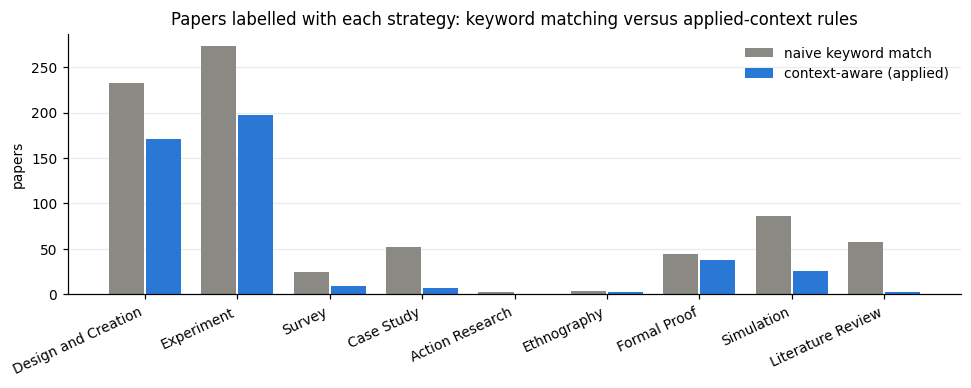

In [20]:
fig, ax = plt.subplots(figsize=(9, 3.6))
positions = np.arange(len(STRATEGIES))
ax.bar(positions - 0.2, prevalence["naive keyword match"], width=0.38, color=GREY, label="naive keyword match")
ax.bar(positions + 0.2, prevalence["context-aware (applied)"], width=0.38, color=BLUE, label="context-aware (applied)")
ax.set_xticks(positions, STRATEGIES, rotation=25, ha="right")
ax.set_ylabel("papers")
ax.set_title("Papers labelled with each strategy: keyword matching versus applied-context rules")
ax.legend(frameon=False)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "naive_vs_context.png", bbox_inches="tight")
plt.show()

The gap between the grey and blue bars shows how many papers keyword matching would label with a methodology that they only discuss. Section 13 checks against the human labels which of the two is closer to a human reading of the paper. The cell below shows the evidence the annotator keeps for one paper.

In [21]:
example = annotations[papers.index[0]]
print(papers.loc[papers.index[0], "title"][:100])
for label, result in example["strategies"].items():
    if result["present"]:
        print(f"\n{label}  score {result['score']}  confidence {result['confidence']}")
        for item in result["evidence"][:2]:
            print(f"    [{item['zone']}] {item['sentence'][:220]}")
print("\ndata generation:", [g for g, r in example["generation"].items() if r["present"]])
print("analysis approach:", example["approach"])

From Safety Documentation to Safety Knowledge Support: An Evidence-Grounded LLM Framework for Medica

Design and Creation  score 6.0  confidence 0.667
    [abstract] We propose an evidence-grounded framework that connects device artifacts, controlled knowledge storage and retrieval, method-specific generation of candidate safety items, critique and uncertainty checks, and recorded ex
    [method] The proposed framework defines a human-in-the-loop support process that addresses the research questions shown in Table IV.

data generation: []
analysis approach: Not determined


## 8. Data Splits and Human Annotation

The corpus is split 70/15/15 into training, validation and test sets, stratified by discipline as planned in the design chapter. The split is saved on the first run and reloaded afterwards, so the test set (and the human annotations made on it) stays fixed. Classical models are compared with 5-fold cross-validation on the development set (training plus validation). SciBERT uses the validation set for early stopping. The test set is used once, at the end, to compare the final models.

In [22]:
SPLIT_FILE = CACHE_DIR / "splits.json"


def safe_split(ids, strata, test_size):
    counts = Counter(strata)
    strata = [s if counts[s] >= 3 else "rare" for s in strata]
    try:
        return train_test_split(ids, test_size=test_size, random_state=SEED, stratify=strata)
    except ValueError:
        return train_test_split(ids, test_size=test_size, random_state=SEED)


saved = json.loads(SPLIT_FILE.read_text()) if SPLIT_FILE.exists() else None
if saved and set(sum(saved.values(), [])) == set(papers.index):
    splits = saved
    print("loaded saved split")
else:
    ids = list(papers.index)
    train_ids, rest_ids = safe_split(ids, papers.loc[ids, "discipline"].tolist(), 0.30)
    val_ids, test_ids = safe_split(rest_ids, papers.loc[rest_ids, "discipline"].tolist(), 0.50)
    splits = {"train": sorted(train_ids), "val": sorted(val_ids), "test": sorted(test_ids)}
    SPLIT_FILE.write_text(json.dumps(splits, indent=1))
    print("created and saved a new split")

TRAIN, VAL, TEST = splits["train"], splits["val"], splits["test"]
DEV = TRAIN + VAL
papers["split"] = ["train" if d in TRAIN else "val" if d in VAL else "test" for d in papers.index]
pd.crosstab(papers["discipline"], papers["split"], margins=True)

loaded saved split


split,test,train,val,All
discipline,,,,
Computer Engineering,0,2,1,3
Computer Science,26,113,25,164
Information Systems,5,20,6,31
Information Technology,3,11,2,16
Other,1,9,0,10
Software Engineering,10,55,11,76
All,45,210,45,300


### 8.1 Human Annotation of the Test Set

The rule labels from Section 7 cannot be used to evaluate themselves, so the 45 test papers were labelled by hand. The first run writes two blank sheets to the annotation folder:

- annotator_1.csv lists every test paper, for the first annotator.
- annotator_2.csv lists a random subset of 30 of those papers (10% of the corpus, as in the design chapter), for a second annotator, so that inter-annotator agreement can be measured.

Each sheet lists only the paper identifier, file name and title, followed by one column per strategy. The two annotators worked independently and did not see each other's labels or the output of the rules. For each paper they read the PDF, concentrating on the method and evaluation sections, and entered 1 or 0 for every strategy using the definitions in Section 3.2. Sheets that already exist are never overwritten, and only rows with a 0 or 1 in every strategy column are loaded.

In [23]:
ANNOTATION_SHEETS = {1: ANNOTATION_DIR / "annotator_1.csv", 2: ANNOTATION_DIR / "annotator_2.csv"}
DOUBLE_ANNOTATED = sorted(random.Random(SEED).sample(TEST, min(30, len(TEST))))


for annotator, doc_ids in [(1, TEST), (2, DOUBLE_ANNOTATED)]:
    if not ANNOTATION_SHEETS[annotator].exists():
        sheet = pd.DataFrame({"doc": doc_ids, "file": [extracted[d]["file"] for d in doc_ids],
                              "title": papers.loc[doc_ids, "title"].values})
        for strategy in STRATEGIES:
            sheet[strategy] = ""
        sheet.to_csv(ANNOTATION_SHEETS[annotator], index=False, encoding="utf-8-sig")
        print(f"wrote blank sheet {ANNOTATION_SHEETS[annotator]} ({len(doc_ids)} papers)")


def load_annotations(path):
    sheet = pd.read_csv(path, dtype=str).fillna("")
    sheet = sheet[sheet[STRATEGIES].apply(lambda row: all(v.strip() in {"0", "1"} for v in row), axis=1)]
    return sheet.set_index("doc")[STRATEGIES].astype(int)


Y_human = load_annotations(ANNOTATION_SHEETS[1])
Y_human_2 = load_annotations(ANNOTATION_SHEETS[2])
HAS_HUMAN_LABELS = len(Y_human) >= 10
print(f"human labels loaded: annotator 1 {len(Y_human)}/{len(TEST)} papers, annotator 2 {len(Y_human_2)}/{len(DOUBLE_ANNOTATED)} papers")
if not HAS_HUMAN_LABELS:
    print("fewer than 10 annotated papers, evaluations against human labels are skipped until the sheets are filled in")

human labels loaded: annotator 1 45/45 papers, annotator 2 30/30 papers


Agreement is measured with Cohen's kappa (the formula is given in the design chapter), which corrects raw agreement for the agreement expected by chance. The design chapter set κ ≥ 0.80 as the bar for trusting the labels. The pooled kappa treats every paper and strategy pair as one decision. Per strategy, kappa is undefined when neither annotator marked any paper with that strategy, because there is no variation to agree on. Those rows are reported as "no positives" together with the raw agreement rate. The rules are also compared with annotator 1, which shows how reliable the rule labels used for training are.

In [24]:
def pooled_kappa(a, b):
    return cohen_kappa_score(a.values.ravel(), b.values.ravel())


def per_strategy_agreement(a, b):
    rows = []
    for strategy in STRATEGIES:
        x, y = a[strategy], b[strategy]
        no_positives = x.sum() == 0 and y.sum() == 0
        rows.append({"strategy": strategy, "annotator 1 positives": int(x.sum()), "annotator 2 positives": int(y.sum()),
                     "raw agreement": (x == y).mean(),
                     "kappa": "no positives" if no_positives else round(cohen_kappa_score(x, y), 3)})
    return pd.DataFrame(rows).set_index("strategy")


if len(Y_human_2) >= 5:
    shared = Y_human.index.intersection(Y_human_2.index)
    kappa = pooled_kappa(Y_human.loc[shared], Y_human_2.loc[shared])
    print(f"inter-annotator agreement on {len(shared)} papers: pooled kappa = {kappa:.3f} "
          f"({'meets' if kappa >= 0.8 else 'below'} the 0.80 threshold)")
    display(per_strategy_agreement(Y_human.loc[shared], Y_human_2.loc[shared]).round(3))
    record_result("8.1", "methodology", "annotator 1 vs annotator 2", "test", "cohen kappa", kappa)
else:
    print("second annotator sheet not filled in yet, inter-annotator kappa not computed")

if HAS_HUMAN_LABELS:
    kappa_rules = pooled_kappa(Y_human, Y_rules.loc[Y_human.index])
    print(f"\nrules versus annotator 1 on {len(Y_human)} papers: pooled kappa = {kappa_rules:.3f}")
    record_result("8.1", "methodology", "rule annotator vs annotator 1", "test", "cohen kappa", kappa_rules)

inter-annotator agreement on 30 papers: pooled kappa = 0.981 (meets the 0.80 threshold)


,annotator 1 positives,annotator 2 positives,raw agreement,kappa
strategy,,,,
Design and Creation,26,25,0.967,0.87
Experiment,28,27,0.967,0.783
Survey,2,2,1.000,1.0
Case Study,1,1,1.000,1.0
Action Research,0,0,1.000,no positives
Ethnography,0,0,1.000,no positives
Formal Proof,6,6,1.000,1.0
Simulation,7,7,1.000,1.0
Literature Review,0,0,1.000,no positives



rules versus annotator 1 on 45 papers: pooled kappa = 0.721


## 9. Preprocessing and Document Views

Each paper is turned into several text views, so later sections can test which parts of a paper carry the signal for each tier. Cleaning for the TF-IDF models lowercases the text and removes URLs, e-mail addresses, citation markers, numbers and symbols. English stop words are removed by the vectoriser. SciBERT gets a lighter clean in Section 15, because its WordPiece tokeniser works best on near-natural text.

In [25]:
CLEAN_PATTERNS = [(re.compile(r"https?://\S+|www\.\S+|\S+@\S+"), " "), (CITATION, " "), (re.compile(r"[^A-Za-z\s\-]"), " "),
                  (re.compile(r"\s-+|-+\s"), " "), (re.compile(r"\s+"), " ")]


def clean_text(text):
    for pattern, replacement in CLEAN_PATTERNS:
        text = pattern.sub(replacement, text)
    return text.lower().strip()


VIEW_ZONES = {
    "abstract": ["abstract"],
    "abstract + introduction": ["abstract", "introduction"],
    "core (method, evaluation)": ["method", "evaluation", "body"],
    "full text": ["abstract", "keywords", "introduction", "related_work", "method", "evaluation", "body",
                  "discussion", "conclusion", "appendix"],
    "abstract + core": ["abstract", "method", "evaluation", "body"],
}


def view_text(segment, view):
    return clean_text(segment["title"] + " " + " ".join(segment["zones"].get(z, "") for z in VIEW_ZONES[view]))


VIEWS = {view: pd.Series({d: view_text(segments[d], view) for d in papers.index}) for view in VIEW_ZONES}
pd.DataFrame({view: texts.str.split().str.len().describe()[["mean", "50%", "min"]] for view, texts in VIEWS.items()}).round(0)

,abstract,abstract + introduction,"core (method, evaluation)",full text,abstract + core
mean,246.0,1053.0,4155.0,7622.0,4390.0
50%,219.0,946.0,3556.0,6816.0,3845.0
min,61.0,153.0,56.0,913.0,492.0


## 10. Discipline and Field Classifiers

The design chapter makes a TF-IDF and linear SVM model the baseline. To check that it is a sensible choice rather than simply assuming so, three other models are compared with it on identical folds. A majority-class predictor is the floor any model must beat. Complement Naive Bayes is a probabilistic model suited to imbalanced text classes. Logistic regression is a discriminative linear model that outputs probabilities. Every model gets the same features: TF-IDF over unigrams and bigrams, capped at 5,000 features as in the design chapter.

Hyperparameters are tuned with nested cross-validation. The outer 5-fold loop estimates performance on unseen papers. Inside each outer training fold, a 3-fold grid search picks the regularisation strength, so the reported score never comes from data used to tune it. The TF-IDF vocabulary is also refitted inside each outer fold. Folds are stratified by field.

In [26]:
def make_vectorizer():
    return TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True, min_df=2, max_df=0.9,
                           stop_words="english", token_pattern=r"(?u)\b[a-z][a-z]+\b")


CANDIDATES = {
    "Majority class": (DummyClassifier(strategy="most_frequent"), {}),
    "Complement Naive Bayes": (ComplementNB(alpha=0.3), {"alpha": [0.1, 0.3, 1.0]}),
    "Logistic Regression": (LogisticRegression(max_iter=3000, class_weight="balanced", C=100), {"C": [10, 100, 1000]}),
    "Linear SVM": (LinearSVC(class_weight="balanced"), {"C": [0.1, 1, 10]}),
}


def stratified_folds(ids, n_splits=5):
    strata = papers.loc[ids, "field"].values
    min_count = min(Counter(strata).values())
    splitter = StratifiedKFold(n_splits, shuffle=True, random_state=SEED) if min_count >= 2 else KFold(n_splits, shuffle=True, random_state=SEED)
    return list(splitter.split(ids, strata))


FOLD_CACHE = {}


def fold_matrices(view, ids=None):
    #vectoriser fitted per outer fold and reused by every model on that view
    ids = ids or DEV
    key = (view, tuple(ids))
    if key not in FOLD_CACHE:
        texts = VIEWS[view].loc[ids].values
        matrices = []
        for train_idx, test_idx in stratified_folds(ids):
            vectorizer = make_vectorizer().fit(texts[train_idx])
            matrices.append((train_idx, test_idx, vectorizer.transform(texts[train_idx]), vectorizer.transform(texts[test_idx])))
        FOLD_CACHE[key] = matrices
    return FOLD_CACHE[key]


def tuned(estimator, grid, X, y):
    estimator = clone(estimator)
    if grid and len(set(y)) > 1 and max(Counter(y).values()) >= 3:
        inner = StratifiedKFold(3, shuffle=True, random_state=SEED)
        return GridSearchCV(estimator, grid, cv=inner, scoring="f1_macro").fit(X, y).best_estimator_
    return estimator.fit(X, y)


def nested_cv_predict(view, labels, model_name, ids=None):
    ids = ids or DEV
    y = labels.loc[ids].values
    estimator, grid = CANDIDATES[model_name]
    predictions = np.empty(len(ids), dtype=object)
    for train_idx, test_idx, X_train, X_test in fold_matrices(view, ids):
        predictions[test_idx] = tuned(estimator, grid, X_train, y[train_idx]).predict(X_test)
    return predictions


def single_label_scores(y_true, y_pred):
    return {"accuracy": accuracy_score(y_true, y_pred), "macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)}

In [27]:
comparison_rows, CV_PREDICTIONS = [], {}
for task in ["discipline", "field"]:
    y_true = papers.loc[DEV, task].values
    for model_name in CANDIDATES:
        predictions = nested_cv_predict("full text", papers[task], model_name)
        CV_PREDICTIONS[(task, model_name)] = predictions
        scores = single_label_scores(y_true, predictions)
        comparison_rows.append({"task": task, "model": model_name, **scores})
        for metric, value in scores.items():
            record_result("10", task, model_name, "dev 5-fold CV", metric, value, "full text view")

model_comparison = pd.DataFrame(comparison_rows)
BEST_MODEL = {task: model_comparison[model_comparison["task"] == task].sort_values("macro F1").iloc[-1]["model"]
              for task in ["discipline", "field"]}
print("selected by cross-validated macro F1:", BEST_MODEL)
model_comparison.round(3)

selected by cross-validated macro F1: {'discipline': 'Linear SVM', 'field': 'Linear SVM'}


,task,model,accuracy,macro F1,weighted F1
0,discipline,Majority class,0.541,0.117,0.380
1,discipline,Complement Naive Bayes,0.792,0.405,0.753
2,discipline,Logistic Regression,0.804,0.413,0.762
3,discipline,Linear SVM,0.808,0.415,0.765
4,field,Majority class,0.424,0.046,0.252
5,field,Complement Naive Bayes,0.694,0.216,0.616
6,field,Logistic Regression,0.710,0.258,0.646
7,field,Linear SVM,0.718,0.277,0.663


The confusion matrices below come from the cross-validated predictions of the selected models, so every paper is predicted by a model that never saw it during training. Values are normalised by row, so the diagonal is the recall for each class.

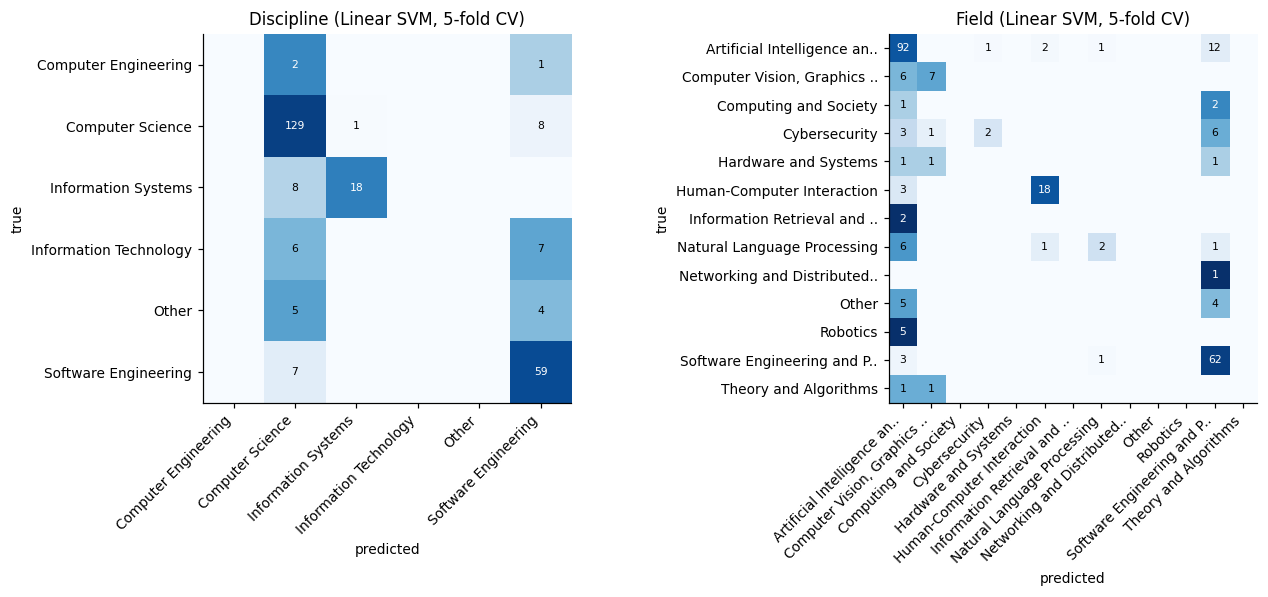

                                                precision    recall  f1-score   support

  Artificial Intelligence and Machine Learning       0.72      0.85      0.78       108
      Computer Vision, Graphics and Multimedia       0.70      0.54      0.61        13
                         Computing and Society       0.00      0.00      0.00         3
                                 Cybersecurity       0.67      0.17      0.27        12
                          Hardware and Systems       0.00      0.00      0.00         3
                    Human-Computer Interaction       0.86      0.86      0.86        21
     Information Retrieval and Data Management       0.00      0.00      0.00         2
                   Natural Language Processing       0.50      0.20      0.29        10
            Networking and Distributed Systems       0.00      0.00      0.00         1
                                         Other       0.00      0.00      0.00         9
                               

In [28]:
def plot_confusion(y_true, y_pred, labels, title, ax):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    normalised = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    ax.imshow(normalised, cmap="Blues", vmin=0, vmax=1)
    short = [label if len(label) < 28 else label[:26] + ".." for label in labels]
    ax.set_xticks(range(len(labels)), short, rotation=45, ha="right")
    ax.set_yticks(range(len(labels)), short)
    for i in range(len(labels)):
        for j in range(len(labels)):
            if matrix[i, j]:
                ax.text(j, i, matrix[i, j], ha="center", va="center", fontsize=7,
                        color="white" if normalised[i, j] > 0.6 else "black")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    ax.grid(False)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1, 1.7]})
for ax, task in zip(axes, ["discipline", "field"]):
    labels = sorted(papers.loc[DEV, task].unique())
    plot_confusion(papers.loc[DEV, task].values, CV_PREDICTIONS[(task, BEST_MODEL[task])], labels,
                   f"{task.title()} ({BEST_MODEL[task]}, 5-fold CV)", ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_cv.png", bbox_inches="tight")
plt.show()
print(classification_report(papers.loc[DEV, "field"].values, CV_PREDICTIONS[("field", BEST_MODEL["field"])], zero_division=0))

## 11. Decoupled Versus Flat Architectures (RQ2)

RQ2 asks whether treating discipline, field and methodology as separate layers works better than a single flat classifier. Four architectures are compared on the same folds, all with a linear SVM so that only the architecture changes:

1. **Decoupled**: independent classifiers for discipline, field and methodology.
2. **Top-down hierarchical**: predict the discipline first, then pick the highest-scoring field within that discipline only.
3. **Bottom-up (flat over fields)**: predict the field directly and read the discipline off the taxonomy.
4. **Flat label powerset**: one single-label classifier over combined labels (field plus the exact set of methodology strategies), with each tier decoded from the predicted combination. This is the "unified single-label flat classification" that RQ2 names.

Besides accuracy, the table reports hierarchical consistency, the share of papers whose predicted field actually belongs to the predicted discipline. Output where the field contradicts the discipline is not useful, even if each tier scores well on its own.

In [29]:
DISCIPLINE_LABELS = sorted(papers["discipline"].unique())
FIELD_LABELS = sorted(papers["field"].unique())


def aligned_scores(model, X, label_order):
    #decision scores reordered to a fixed label list, classes unseen in training get a very low score
    raw = model.decision_function(X)
    if raw.ndim == 1:
        raw = np.column_stack([-raw, raw])
    scores = np.full((X.shape[0], len(label_order)), -1e9)
    for column, label in enumerate(model.classes_):
        scores[:, label_order.index(label)] = raw[:, column]
    return scores


def cv_decision_scores(view, task, label_order, ids=None):
    ids = ids or DEV
    y = papers.loc[ids, task].values
    scores = np.zeros((len(ids), len(label_order)))
    for train_idx, test_idx, X_train, X_test in fold_matrices(view, ids):
        scores[test_idx] = aligned_scores(LinearSVC(class_weight="balanced").fit(X_train, y[train_idx]), X_test, label_order)
    return scores


def top_down(discipline_scores, field_scores):
    disciplines = [DISCIPLINE_LABELS[i] for i in discipline_scores.argmax(axis=1)]
    fields = []
    for row, discipline in zip(field_scores, disciplines):
        allowed = [i for i, f in enumerate(FIELD_LABELS) if FIELD_TO_DISCIPLINE[f] == discipline]
        fields.append(FIELD_LABELS[max(allowed, key=lambda i: row[i])] if allowed else FIELD_LABELS[row.argmax()])
    return disciplines, fields


def ovr_cv_predict(view, Y, ids=None):
    ids = ids or DEV
    Y = Y.loc[ids].values
    predictions, scores = np.zeros_like(Y), np.zeros(Y.shape, dtype=float)
    for train_idx, test_idx, X_train, X_test in fold_matrices(view, ids):
        for j in range(Y.shape[1]):
            if Y[train_idx, j].sum() == 0 or Y[train_idx, j].all():
                scores[test_idx, j] = -1.0 if Y[train_idx, j].sum() == 0 else 1.0
            else:
                scores[test_idx, j] = LinearSVC(class_weight="balanced").fit(X_train, Y[train_idx, j]).decision_function(X_test)
        predictions[test_idx] = (scores[test_idx] > 0).astype(int)
    return predictions, scores


def multilabel_scores(Y_true, Y_pred):
    Y_true, Y_pred = np.asarray(Y_true), np.asarray(Y_pred)
    return {"micro F1": f1_score(Y_true, Y_pred, average="micro", zero_division=0),
            "macro F1": f1_score(Y_true, Y_pred, average="macro", zero_division=0),
            "exact match": float((Y_true == Y_pred).all(axis=1).mean())}

In [30]:
true_discipline = papers.loc[DEV, "discipline"].values
true_field = papers.loc[DEV, "field"].values
discipline_scores = cv_decision_scores("full text", "discipline", DISCIPLINE_LABELS)
field_scores = cv_decision_scores("full text", "field", FIELD_LABELS)
decoupled_discipline = [DISCIPLINE_LABELS[i] for i in discipline_scores.argmax(axis=1)]
decoupled_field = [FIELD_LABELS[i] for i in field_scores.argmax(axis=1)]
topdown_discipline, topdown_field = top_down(discipline_scores, field_scores)
bottomup_field = decoupled_field
bottomup_discipline = [FIELD_TO_DISCIPLINE[f] for f in bottomup_field]
decoupled_methodology, _ = ovr_cv_predict("abstract + core", Y_rules)

joint_labels = pd.Series({d: papers.loc[d, "field"] + " | " + ",".join(s for s in STRATEGIES if Y_rules.loc[d, s])
                          for d in papers.index})
joint_predictions = nested_cv_predict("full text", joint_labels, "Linear SVM")
powerset_field = [label.split(" | ")[0] for label in joint_predictions]
powerset_discipline = [FIELD_TO_DISCIPLINE[f] for f in powerset_field]
powerset_methodology = np.array([[int(s in label.split(" | ")[1].split(",")) for s in STRATEGIES] for label in joint_predictions])

architectures = {
    "Decoupled": (decoupled_discipline, decoupled_field, decoupled_methodology),
    "Top-down hierarchical": (topdown_discipline, topdown_field, decoupled_methodology),
    "Bottom-up (flat over fields)": (bottomup_discipline, bottomup_field, decoupled_methodology),
    "Flat label powerset": (powerset_discipline, powerset_field, powerset_methodology),
}
rq2_rows = []
for name, (disc, field, method) in architectures.items():
    consistency = np.mean([FIELD_TO_DISCIPLINE[f] == d for f, d in zip(field, disc)])
    method_scores = multilabel_scores(Y_rules.loc[DEV].values, method)
    row = {"architecture": name, "discipline accuracy": accuracy_score(true_discipline, disc),
           "discipline macro F1": f1_score(true_discipline, disc, average="macro", zero_division=0),
           "field accuracy": accuracy_score(true_field, field),
           "field macro F1": f1_score(true_field, field, average="macro", zero_division=0),
           "hierarchical consistency": consistency, "methodology micro F1 (vs rule labels)": method_scores["micro F1"]}
    rq2_rows.append(row)
    for metric, value in row.items():
        if metric != "architecture":
            record_result("11", "RQ2", name, "dev 5-fold CV", metric, value)
print(f"distinct flat powerset classes: {joint_labels.loc[DEV].nunique()} for {len(DEV)} papers")
rq2_table = pd.DataFrame(rq2_rows).set_index("architecture")
HIERARCHY_STRATEGY = rq2_table[["discipline macro F1", "field macro F1"]].drop("Flat label powerset").mean(axis=1).idxmax()
print("hierarchy strategy used by the final pipeline:", HIERARCHY_STRATEGY)
rq2_table.round(3)

distinct flat powerset classes: 73 for 255 papers
hierarchy strategy used by the final pipeline: Bottom-up (flat over fields)


,discipline accuracy,discipline macro F1,field accuracy,field macro F1,hierarchical consistency,methodology micro F1 (vs rule labels)
architecture,,,,,,
Decoupled,0.808,0.415,0.718,0.277,0.937,0.764
Top-down hierarchical,0.808,0.415,0.718,0.255,1.000,0.764
Bottom-up (flat over fields),0.796,0.447,0.718,0.277,1.000,0.764
Flat label powerset,0.816,0.473,0.710,0.275,1.000,0.694


The powerset model has to learn one class per combination of field and strategies, so most combinations have only one or two training papers. This is the negative interference the design chapter predicted: sharing one output space across tiers means each class has far fewer examples. The final pipeline uses whichever of the other three architectures scores highest on mean macro F1 across discipline and field (printed above).

## 12. Which Document Zones Carry the Signal (RQ1, RQ3)

The same linear SVM is trained on each text view from Section 9, one at a time. For discipline and field, the labels are independent of the text, so this is a clean test of where the topical signal sits. For methodology, the targets are the rule labels, which the rules derived from the abstract and core zones. Methodology scores on those views are therefore partly agreement with the rules, and the comparison with human labels in Section 13 is the fairer test.

In [31]:
ablation_rows = []
for view in VIEWS:
    disc_pred = [DISCIPLINE_LABELS[i] for i in cv_decision_scores(view, "discipline", DISCIPLINE_LABELS).argmax(axis=1)]
    field_pred = [FIELD_LABELS[i] for i in cv_decision_scores(view, "field", FIELD_LABELS).argmax(axis=1)]
    method_pred, _ = ovr_cv_predict(view, Y_rules)
    row = {"view": view, "mean words": VIEWS[view].loc[DEV].str.split().str.len().mean(),
           "discipline macro F1": f1_score(true_discipline, disc_pred, average="macro", zero_division=0),
           "field macro F1": f1_score(true_field, field_pred, average="macro", zero_division=0),
           "methodology micro F1 (vs rule labels)": multilabel_scores(Y_rules.loc[DEV].values, method_pred)["micro F1"]}
    ablation_rows.append(row)
    for metric in ["discipline macro F1", "field macro F1", "methodology micro F1 (vs rule labels)"]:
        record_result("12", "zone ablation", "Linear SVM", "dev 5-fold CV", metric, row[metric], view)
ablation = pd.DataFrame(ablation_rows).set_index("view")
ablation.round(3)

,mean words,discipline macro F1,field macro F1,methodology micro F1 (vs rule labels)
view,,,,
abstract,248.353,0.376,0.209,0.738
abstract + introduction,1057.451,0.432,0.248,0.747
"core (method, evaluation)",4147.733,0.425,0.264,0.762
full text,7632.031,0.415,0.277,0.763
abstract + core,4385.075,0.398,0.265,0.764


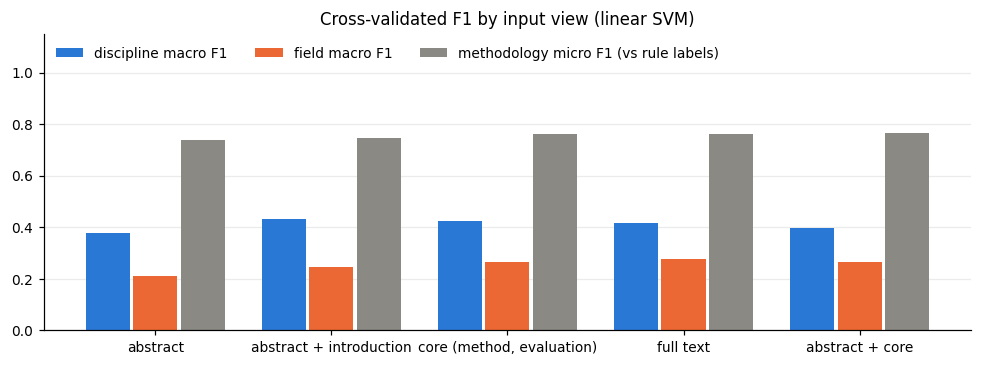

In [32]:
fig, ax = plt.subplots(figsize=(9, 3.4))
metrics = ["discipline macro F1", "field macro F1", "methodology micro F1 (vs rule labels)"]
colours = [BLUE, ORANGE, GREY]
positions = np.arange(len(ablation))
for k, (metric, colour) in enumerate(zip(metrics, colours)):
    ax.bar(positions + (k - 1) * 0.27, ablation[metric], width=0.25, color=colour, label=metric)
ax.set_xticks(positions, ablation.index)
ax.set_ylim(0, 1.15)
ax.set_title("Cross-validated F1 by input view (linear SVM)")
ax.legend(frameon=False, ncol=3, loc="upper left")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "zone_ablation.png", bbox_inches="tight")
plt.show()

## 13. Methodology Classifier (RQ1)

A one-vs-rest linear SVM is trained on the abstract and core zones, with one binary classifier per strategy, using the rule labels from Section 7 as targets. This follows the design chapter's multi-label SVM baseline. Logistic regression is compared on the same folds. A strategy needs at least 8 positive and 8 negative development papers to get a learned classifier. Rarer strategies (typically action research and ethnography in an arXiv sample) are handled by the rules alone, because a classifier trained on a handful of examples would add nothing but noise.

In [33]:
MIN_POSITIVES = 8
positives = Y_rules.loc[DEV].sum()
TRAINABLE = [s for s in STRATEGIES if MIN_POSITIVES <= positives[s] <= len(DEV) - MIN_POSITIVES]
RULE_ONLY = [s for s in STRATEGIES if s not in TRAINABLE]
print("learned classifiers for:", TRAINABLE)
print("rules only (too few examples):", RULE_ONLY)

METHOD_VIEW = "abstract + core"
svm_pred, _ = ovr_cv_predict(METHOD_VIEW, Y_rules[TRAINABLE])


def lr_ovr_cv_predict(view, Y):
    Y = Y.loc[DEV].values
    predictions = np.zeros_like(Y)
    for train_idx, test_idx, X_train, X_test in fold_matrices(view):
        for j in range(Y.shape[1]):
            model = LogisticRegression(max_iter=3000, class_weight="balanced", C=10).fit(X_train, Y[train_idx, j])
            predictions[test_idx, j] = model.predict(X_test)
    return predictions


lr_pred = lr_ovr_cv_predict(METHOD_VIEW, Y_rules[TRAINABLE])
per_label = []
for j, strategy in enumerate(TRAINABLE):
    for name, pred in [("Linear SVM", svm_pred), ("Logistic Regression", lr_pred)]:
        p, r, f, _ = precision_recall_fscore_support(Y_rules.loc[DEV, strategy], pred[:, j], average="binary", zero_division=0)
        per_label.append({"strategy": strategy, "model": name, "precision": p, "recall": r, "F1": f,
                          "positives": int(positives[strategy])})
per_label = pd.DataFrame(per_label)
for name, pred in [("Linear SVM", svm_pred), ("Logistic Regression", lr_pred)]:
    for metric, value in multilabel_scores(Y_rules.loc[DEV, TRAINABLE].values, pred).items():
        record_result("13", "methodology", name, "dev 5-fold CV vs rule labels", metric, value, METHOD_VIEW)
per_label.pivot(index="strategy", columns="model", values="F1").round(3)

learned classifiers for: ['Design and Creation', 'Experiment', 'Formal Proof', 'Simulation']
rules only (too few examples): ['Survey', 'Case Study', 'Action Research', 'Ethnography', 'Literature Review']


model,Linear SVM,Logistic Regression
strategy,,
Design and Creation,0.753,0.752
Experiment,0.856,0.861
Formal Proof,0.778,0.764
Simulation,0.000,0.000


Agreement with the rule labels only shows that the classifiers can reproduce the rules from the wording of the text. The more important question for RQ1 is which approach matches a human reader. The cell below evaluates four approaches on the human-annotated test papers:

1. **Naive keyword matching**: the approach criticised in the literature review, where any cue anywhere in the paper assigns the label.
2. **Context-aware rules**: the Section 7 annotator, which counts only applied mentions.
3. **SVM**: the learned classifiers, trained on the rule labels of the development papers. Rule-only strategies fall back to the rules.
4. **Hybrid**: a label is assigned if the rules find applied evidence or the SVM is confident. This is the configuration used in the final pipeline.

In [34]:
def fit_methodology_model(ids):
    vectorizer = make_vectorizer().fit(VIEWS[METHOD_VIEW].loc[ids])
    X = vectorizer.transform(VIEWS[METHOD_VIEW].loc[ids])
    models = {s: LinearSVC(class_weight="balanced").fit(X, Y_rules.loc[ids, s]) for s in TRAINABLE}
    return {"vectorizer": vectorizer, "models": models}


def methodology_scores(model, texts):
    X = model["vectorizer"].transform(texts)
    return pd.DataFrame({s: clf.decision_function(X) for s, clf in model["models"].items()}, index=texts.index)


methodology_model = fit_methodology_model(DEV)
test_method_scores = methodology_scores(methodology_model, VIEWS[METHOD_VIEW].loc[TEST])
svm_test = Y_rules.loc[TEST].copy()
svm_test[TRAINABLE] = (test_method_scores[TRAINABLE] > 0).astype(int)
HYBRID_MARGIN = 0.5
hybrid_test = Y_rules.loc[TEST].copy()
hybrid_test[TRAINABLE] = ((Y_rules.loc[TEST, TRAINABLE] == 1) | (test_method_scores[TRAINABLE] > HYBRID_MARGIN)).astype(int)
APPROACHES = {"Naive keyword matching": Y_naive.loc[TEST], "Context-aware rules": Y_rules.loc[TEST],
              "SVM (trained on rule labels)": svm_test, "Hybrid (final pipeline)": hybrid_test}

if HAS_HUMAN_LABELS:
    human_ids = Y_human.index.intersection(TEST)
    rows = []
    for name, predictions in APPROACHES.items():
        scores = multilabel_scores(Y_human.loc[human_ids].values, predictions.loc[human_ids].values)
        rows.append({"approach": name, **scores})
        for metric, value in scores.items():
            record_result("13", "methodology", name, "test vs human labels", metric, value)
    display(pd.DataFrame(rows).set_index("approach").round(3))
    per_strategy = pd.DataFrame({name: [f1_score(Y_human.loc[human_ids, s], preds.loc[human_ids, s], zero_division=0) for s in STRATEGIES]
                                 for name, preds in APPROACHES.items()}, index=STRATEGIES)
    per_strategy["positives (human labels)"] = Y_human.loc[human_ids].sum()
    display(per_strategy.round(3))
else:
    rows = [{"approach": name, **multilabel_scores(Y_rules.loc[TEST].values, p.values)} for name, p in APPROACHES.items()]
    print("no human labels yet, showing agreement with the rule labels on the test split instead")
    display(pd.DataFrame(rows).set_index("approach").round(3))

,micro F1,macro F1,exact match
approach,,,
Naive keyword matching,0.778,0.473,0.311
Context-aware rules,0.775,0.424,0.467
SVM (trained on rule labels),0.783,0.348,0.356
Hybrid (final pipeline),0.780,0.425,0.444


,Naive keyword matching,Context-aware rules,SVM (trained on rule labels),Hybrid (final pipeline),positives (human labels)
Design and Creation,0.829,0.800,0.806,0.794,35
Experiment,0.911,0.831,0.930,0.848,37
Survey,0.600,0.800,0.800,0.800,3
Case Study,0.333,0.000,0.000,0.000,3
Action Research,0.000,0.000,0.000,0.000,0
Ethnography,0.000,0.000,0.000,0.000,0
Formal Proof,1.000,0.923,0.600,0.923,7
Simulation,0.583,0.462,0.000,0.462,8
Literature Review,0.000,0.000,0.000,0.000,0


## 14. Interpretability (RQ3)

Because the baseline models are linear, their coefficients show which terms push a paper toward each class. This answers RQ3 for the learned models, and it can also expose shortcut features. For example, a venue name or template phrase that predicts a class for the wrong reason would show up here.

In [35]:
def top_terms(model, vectorizer, n=10):
    names = np.array(vectorizer.get_feature_names_out())
    coefficients = model.coef_ if model.coef_.shape[0] > 1 else np.vstack([-model.coef_[0], model.coef_[0]])
    return {label: ", ".join(names[np.argsort(row)[-n:][::-1]]) for label, row in zip(model.classes_, coefficients)}


discipline_vectorizer = make_vectorizer().fit(VIEWS["full text"].loc[DEV])
discipline_svm = LinearSVC(class_weight="balanced").fit(discipline_vectorizer.transform(VIEWS["full text"].loc[DEV]),
                                                         papers.loc[DEV, "discipline"])
pd.DataFrame.from_dict(top_terms(discipline_svm, discipline_vectorizer), orient="index", columns=["strongest terms"])

,strongest terms
Computer Engineering,"lstm, rtl, ffl, robots, rs, eeg, familiarity, inst, faces, unfamiliar"
Computer Science,"reward, rl, supervised, appendix, domain, rewards, segment, time series, theorem, rollout"
Information Systems,"engagement, participants, users, social, recourse, people, cues, media, agency, override"
Information Technology,"attack, attacks, security, adversarial, cwe, vulnerability, attacker, injection, vulnerable, sec"
Other,"bioinformatics, rna, cfd, slurm, ng, material, rust, buildings, phys, dens"
Software Engineering,"rq, software engineering, software, engineering, projects, repository, testing, development, test cases, fault"


In [36]:
method_names = np.array(methodology_model["vectorizer"].get_feature_names_out())
pd.DataFrame.from_dict({s: ", ".join(method_names[np.argsort(clf.coef_[0])[-10:][::-1]])
                        for s, clf in methodology_model["models"].items()}, orient="index", columns=["strongest terms"])

,strongest terms
Design and Creation,"proposed, agent, mini, node, accuracy, scaling, physical, guide, detection, training data"
Experiment,"baseline, baselines, experiments, target, ablation, hypothesis, mean, variants, test, generates"
Formal Proof,"theorem, proposition, proof, finite, corollary, assumption, holds, convex, shortcut, let"
Simulation,"simulation, simulated, simulator, collision, lstm, cumulative, carlo, monte, monte carlo, trials"


For the rule-based annotator, interpretability is built in. The table below counts which individual cues fired in applied contexts across the corpus, which shows which phrasings authors actually use to report each strategy.

In [37]:
cue_hits = Counter()
for doc_id in papers.index:
    for zone, sentence in document_sentences(segments[doc_id]):
        if zone in EXCLUDED_ZONES:
            continue
        for label, patterns in STRATEGY_CUES.items():
            for pattern, _ in patterns:
                match = pattern.search(sentence)
                if match:
                    cue_hits[(label, match.group(0).lower()[:40])] += 1
cue_table = pd.DataFrame([{"strategy": k[0], "matched text": k[1], "sentences": v} for k, v in cue_hits.items()])
cue_table.sort_values("sentences", ascending=False).groupby("strategy").head(3).sort_values(["strategy", "sentences"], ascending=[True, False]).set_index("strategy")

,matched text,sentences
strategy,,
Action Research,research cycle,1
Case Study,single case,8
Case Study,a case study,7
Case Study,single organization,6
Design and Creation,our approach,124
Design and Creation,our method,86
Design and Creation,our framework,71
Ethnography,fieldwork,3
Ethnography,ethnographic,1


## 15. Multi-Task SciBERT (RQ1, RQ2)

This is the deep learning model from the design chapter. One SciBERT encoder (Beltagy, Lo and Cohan, 2019) is shared by three task heads: softmax heads for discipline and field, and a sigmoid head for the nine methodology strategies, trained with binary cross-entropy. Sharing the encoder means one fine-tuning run instead of three, while each tier keeps its own output layer, which is the decoupled design argued for in RQ2.

SciBERT reads at most 512 tokens at a time, but a paper runs to thousands. Rather than cutting everything after the first 512 tokens, each paper's title, abstract and core zones are split into up to four overlapping 512-token chunks. Each chunk is encoded, and the [CLS] vectors of a paper's chunks are averaged into one document vector before the task heads. This lets the methodology head see the method section and not only the abstract.

The training settings target a 12 GB GPU (RTX 4070 Super): fp16 mixed precision, gradient checkpointing, two papers (up to eight chunks) per step, and 8 steps of gradient accumulation, for an effective batch of 16 papers. The encoder learning rate is 2e-5 and the new heads use 1e-3, with linear warm-up and decay. Discipline and field losses use inverse-frequency class weights, and the methodology loss uses per-label positive weights, following the design chapter's class imbalance plan. Training stops early when the validation score has not improved for three epochs, and the best checkpoint is saved. When a saved checkpoint exists and was trained on the current labels and split, it is loaded instead of retraining. If the labels have changed since, for example after the rules are updated, the model is trained again automatically.

In [38]:
import os
import hashlib

#tqdm warns when ipywidgets is missing, the hub warns about anonymous downloads, both harmless
warnings.filterwarnings("ignore", message="IProgress not found")
os.environ["HF_HUB_VERBOSITY"] = "error"

try:
    import torch
    import torch.nn as nn
    from transformers import AutoTokenizer, AutoModel
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
    hf_logging.disable_progress_bar()
    TORCH_READY = True
except ImportError:
    TORCH_READY = False

MODEL_NAME = "allenai/scibert_scivocab_uncased"
MAX_LENGTH, MAX_CHUNKS, STRIDE = 512, 4, 64
DOCS_PER_STEP, GRAD_ACCUM = 2, 8
ENCODER_LR, HEAD_LR, WEIGHT_DECAY = 2e-5, 1e-3, 0.01
EPOCHS, PATIENCE, WARMUP_SHARE = 15, 3, 0.1
CHECKPOINT = MODEL_DIR / "scibert_multitask.pt"
HISTORY_FILE = MODEL_DIR / "scibert_history.json"
FINGERPRINT_FILE = MODEL_DIR / "scibert_fingerprint.txt"
RETRAIN = False
FORCE_CPU_TRAINING = False

#a saved checkpoint is only reused if it was trained on exactly the current labels and split
LABEL_FINGERPRINT = hashlib.sha1(json.dumps([DISCIPLINE_LABELS, FIELD_LABELS, STRATEGIES, TRAIN,
                                             papers.loc[TRAIN, ["discipline", "field"]].values.tolist(),
                                             Y_rules.loc[TRAIN].values.tolist()]).encode()).hexdigest()
CHECKPOINT_VALID = (not RETRAIN and CHECKPOINT.exists() and FINGERPRINT_FILE.exists()
                    and FINGERPRINT_FILE.read_text() == LABEL_FINGERPRINT)

if TORCH_READY:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(SEED)
    print("torch", torch.__version__, "| device:", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "cpu")
RUN_SCIBERT = TORCH_READY and (DEVICE.type == "cuda" or FORCE_CPU_TRAINING or CHECKPOINT_VALID)
if not RUN_SCIBERT:
    print("SciBERT skipped: needs torch, transformers and a CUDA GPU (or FORCE_CPU_TRAINING = True, which is very slow)")

torch 2.11.0+cu128 | device: NVIDIA GeForce RTX 4070 SUPER


In [39]:
LIGHT_CLEAN = [(re.compile(r"https?://\S+|\S+@\S+"), " "), (CITATION, " "), (re.compile(r"\s+"), " ")]


def scibert_text(segment):
    text = segment["title"] + ". " + " ".join(segment["zones"].get(z, "") for z in VIEW_ZONES["abstract + core"])
    for pattern, replacement in LIGHT_CLEAN:
        text = pattern.sub(replacement, text)
    return text.strip()


if RUN_SCIBERT:
    class MultiTaskSciBERT(nn.Module):
        def __init__(self, n_discipline, n_field, n_methodology, dropout=0.1):
            super().__init__()
            self.encoder = AutoModel.from_pretrained(MODEL_NAME)
            self.encoder.gradient_checkpointing_enable()
            hidden = self.encoder.config.hidden_size
            self.dropout = nn.Dropout(dropout)
            self.discipline_head = nn.Linear(hidden, n_discipline)
            self.field_head = nn.Linear(hidden, n_field)
            self.methodology_head = nn.Linear(hidden, n_methodology)

        def forward(self, input_ids, attention_mask, doc_index, n_docs):
            cls = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0]
            #average the chunk vectors of each paper
            pooled = torch.zeros(n_docs, cls.size(1), device=cls.device, dtype=cls.dtype).index_add_(0, doc_index, cls)
            pooled = pooled / torch.bincount(doc_index, minlength=n_docs).clamp(min=1).unsqueeze(1).to(cls.dtype)
            pooled = self.dropout(pooled)
            return self.discipline_head(pooled), self.field_head(pooled), self.methodology_head(pooled)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    def encode(text):
        encoding = tokenizer(text, max_length=MAX_LENGTH, truncation=True, stride=STRIDE,
                             return_overflowing_tokens=True, padding="max_length")
        return torch.tensor(encoding["input_ids"][:MAX_CHUNKS]), torch.tensor(encoding["attention_mask"][:MAX_CHUNKS])

    ENCODED = {d: encode(scibert_text(segments[d])) for d in papers.index}
    TARGETS = {d: (DISCIPLINE_LABELS.index(papers.loc[d, "discipline"]), FIELD_LABELS.index(papers.loc[d, "field"]),
                   Y_rules.loc[d, STRATEGIES].values.astype(np.float32)) for d in papers.index}
    print(f"encoded {len(ENCODED)} papers, mean chunks per paper {np.mean([v[0].shape[0] for v in ENCODED.values()]):.2f}")

encoded 300 papers, mean chunks per paper 3.98


In [40]:
def batches(ids, encoded, shuffle=False):
    order = list(ids)
    if shuffle:
        random.shuffle(order)
    for start in range(0, len(order), DOCS_PER_STEP):
        batch_ids = order[start:start + DOCS_PER_STEP]
        chunks = [encoded[d] for d in batch_ids]
        doc_index = torch.cat([torch.full((c[0].shape[0],), k, dtype=torch.long) for k, c in enumerate(chunks)])
        yield batch_ids, torch.cat([c[0] for c in chunks]), torch.cat([c[1] for c in chunks]), doc_index


def run_model(model, ids, encoded):
    model.eval()
    outputs = {"discipline": [], "field": [], "methodology": []}
    with torch.no_grad(), torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
        for batch_ids, input_ids, mask, doc_index in batches(ids, encoded):
            d, f, m = model(input_ids.to(DEVICE), mask.to(DEVICE), doc_index.to(DEVICE), len(batch_ids))
            outputs["discipline"].append(torch.softmax(d.float(), -1).cpu())
            outputs["field"].append(torch.softmax(f.float(), -1).cpu())
            outputs["methodology"].append(torch.sigmoid(m.float()).cpu())
    return {k: torch.cat(v).numpy() for k, v in outputs.items()}


def score_probabilities(probs, ids):
    disc = [DISCIPLINE_LABELS[i] for i in probs["discipline"].argmax(1)]
    field = [FIELD_LABELS[i] for i in probs["field"].argmax(1)]
    method = (probs["methodology"] > 0.5).astype(int)
    return {"discipline macro F1": f1_score(papers.loc[ids, "discipline"], disc, average="macro", zero_division=0),
            "field macro F1": f1_score(papers.loc[ids, "field"], field, average="macro", zero_division=0),
            "methodology micro F1 (vs rule labels)": f1_score(Y_rules.loc[ids, STRATEGIES].values, method, average="micro", zero_division=0)}


def class_weights(labels, n_classes):
    counts = np.bincount(labels, minlength=n_classes).astype(float)
    weights = np.where(counts > 0, counts.sum() / (n_classes * np.maximum(counts, 1)), 1.0)
    return torch.tensor(weights, dtype=torch.float32)


def train_scibert(train_ids, val_ids):
    model = MultiTaskSciBERT(len(DISCIPLINE_LABELS), len(FIELD_LABELS), len(STRATEGIES)).to(DEVICE)
    head_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
    optimizer = torch.optim.AdamW([{"params": model.encoder.parameters(), "lr": ENCODER_LR},
                                   {"params": head_params, "lr": HEAD_LR}], weight_decay=WEIGHT_DECAY)
    steps_per_epoch = int(np.ceil(len(train_ids) / (DOCS_PER_STEP * GRAD_ACCUM)))
    total_steps, warmup = EPOCHS * steps_per_epoch, max(1, int(WARMUP_SHARE * EPOCHS * steps_per_epoch))
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda step: min((step + 1) / warmup, max(0.0, (total_steps - step) / max(1, total_steps - warmup))))
    scaler = torch.amp.GradScaler(DEVICE.type, enabled=DEVICE.type == "cuda")

    y_disc = np.array([TARGETS[d][0] for d in train_ids])
    y_field = np.array([TARGETS[d][1] for d in train_ids])
    y_method = np.stack([TARGETS[d][2] for d in train_ids])
    ce_disc = nn.CrossEntropyLoss(weight=class_weights(y_disc, len(DISCIPLINE_LABELS)).to(DEVICE))
    ce_field = nn.CrossEntropyLoss(weight=class_weights(y_field, len(FIELD_LABELS)).to(DEVICE))
    pos = y_method.sum(0)
    pos_weight = torch.tensor(np.clip((len(y_method) - pos) / np.maximum(pos, 1), 1, 10), dtype=torch.float32)
    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))

    def batch_loss(batch_ids, input_ids, mask, doc_index):
        d, f, m = model(input_ids.to(DEVICE), mask.to(DEVICE), doc_index.to(DEVICE), len(batch_ids))
        target_d = torch.tensor([TARGETS[x][0] for x in batch_ids], device=DEVICE)
        target_f = torch.tensor([TARGETS[x][1] for x in batch_ids], device=DEVICE)
        target_m = torch.tensor(np.stack([TARGETS[x][2] for x in batch_ids]), device=DEVICE)
        return ce_disc(d.float(), target_d) + ce_field(f.float(), target_f) + bce(m.float(), target_m)

    history, best_score, best_state, stale = [], -1.0, None, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        start, running, n_batches = time.time(), 0.0, 0
        optimizer.zero_grad()
        for step, batch in enumerate(batches(train_ids, ENCODED, shuffle=True), 1):
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
                loss = batch_loss(*batch)
            scaler.scale(loss / GRAD_ACCUM).backward()
            if step % GRAD_ACCUM == 0 or step * DOCS_PER_STEP >= len(train_ids):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
            running, n_batches = running + loss.item(), n_batches + 1

        model.eval()
        with torch.no_grad(), torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=DEVICE.type == "cuda"):
            val_loss = np.mean([batch_loss(*batch).item() for batch in batches(val_ids, ENCODED)])
        val_scores = score_probabilities(run_model(model, val_ids, ENCODED), val_ids)
        val_score = float(np.mean(list(val_scores.values())))
        history.append({"epoch": epoch, "train loss": running / n_batches, "val loss": float(val_loss),
                        "val score": val_score, **val_scores})
        print(f"epoch {epoch:2d}  train loss {running / n_batches:.3f}  val loss {val_loss:.3f}  "
              f"val score {val_score:.3f}  ({time.time() - start:.0f}s)")
        if val_score > best_score:
            best_score, stale = val_score, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= PATIENCE:
                print(f"early stopping, best validation score {best_score:.3f}")
                break

    model.load_state_dict(best_state)
    torch.save(best_state, CHECKPOINT)
    HISTORY_FILE.write_text(json.dumps(history))
    return model, history

In [41]:
SCIBERT_PROBS = {}
if RUN_SCIBERT:
    if CHECKPOINT_VALID:
        scibert = MultiTaskSciBERT(len(DISCIPLINE_LABELS), len(FIELD_LABELS), len(STRATEGIES)).to(DEVICE)
        scibert.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
        scibert_history = json.loads(HISTORY_FILE.read_text()) if HISTORY_FILE.exists() else []
        print("loaded saved checkpoint, set RETRAIN = True to train again")
    else:
        if CHECKPOINT.exists() and not RETRAIN:
            print("labels or split changed since the saved checkpoint was trained, training again")
        scibert, scibert_history = train_scibert(TRAIN, VAL)
        FINGERPRINT_FILE.write_text(LABEL_FINGERPRINT)
    SCIBERT_PROBS = {"val": run_model(scibert, VAL, ENCODED), "test": run_model(scibert, TEST, ENCODED)}
    print("validation:", {k: round(v, 3) for k, v in score_probabilities(SCIBERT_PROBS["val"], VAL).items()})

loaded saved checkpoint, set RETRAIN = True to train again
validation: {'discipline macro F1': 0.556, 'field macro F1': 0.424, 'methodology micro F1 (vs rule labels)': 0.741}


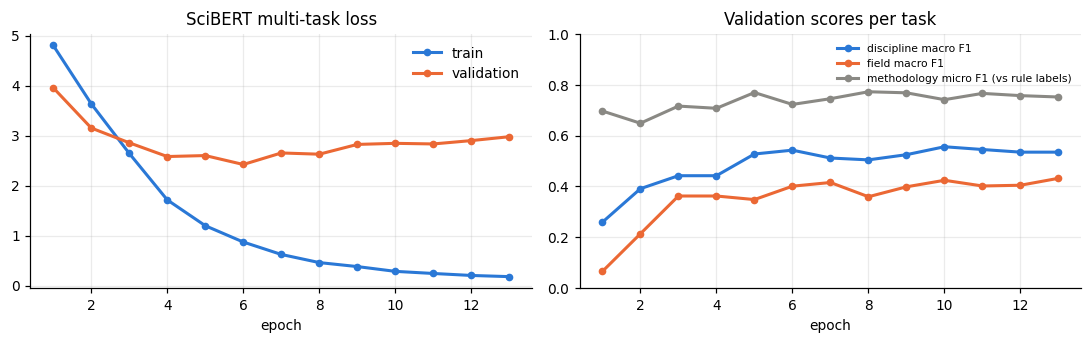

In [42]:
if RUN_SCIBERT and scibert_history:
    history = pd.DataFrame(scibert_history)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].plot(history["epoch"], history["train loss"], color=BLUE, lw=2, marker="o", ms=4, label="train")
    axes[0].plot(history["epoch"], history["val loss"], color=ORANGE, lw=2, marker="o", ms=4, label="validation")
    axes[0].set_title("SciBERT multi-task loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend(frameon=False)
    for metric, colour in zip(["discipline macro F1", "field macro F1", "methodology micro F1 (vs rule labels)"], [BLUE, ORANGE, GREY]):
        axes[1].plot(history["epoch"], history[metric], color=colour, lw=2, marker="o", ms=4, label=metric)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Validation scores per task")
    axes[1].set_xlabel("epoch")
    axes[1].legend(frameon=False, fontsize=7)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "scibert_training.png", bbox_inches="tight")
    plt.show()

## 16. Held-Out Test Evaluation

For a fair comparison, the classical models are refitted on the training split only, the same data SciBERT learned from, with hyperparameters tuned inside that split. For each tier, the backend that scores higher on the validation split is chosen for the final pipeline. The test split is then scored once for both backends. The selection never looks at test results.

In [43]:
def fit_classifier(task, ids, view="full text"):
    vectorizer = make_vectorizer().fit(VIEWS[view].loc[ids])
    X = vectorizer.transform(VIEWS[view].loc[ids])
    estimator, grid = CANDIDATES[BEST_MODEL[task]]
    return {"vectorizer": vectorizer, "model": tuned(estimator, grid, X, papers.loc[ids, task].values), "view": view}


def classifier_scores(fitted, texts, label_order):
    X = fitted["vectorizer"].transform(texts)
    model = fitted["model"]
    if hasattr(model, "decision_function"):
        return aligned_scores(model, X, label_order)
    probabilities = np.full((X.shape[0], len(label_order)), 1e-9)
    for column, label in enumerate(model.classes_):
        probabilities[:, label_order.index(label)] = model.predict_proba(X)[:, column]
    return np.log(probabilities)


def softmax(scores):
    exp = np.exp(scores - scores.max(axis=1, keepdims=True))
    return exp / exp.sum(axis=1, keepdims=True)


def resolve_hierarchy(discipline_scores, field_scores):
    if HIERARCHY_STRATEGY == "Top-down hierarchical":
        return top_down(discipline_scores, field_scores)
    fields = [FIELD_LABELS[i] for i in field_scores.argmax(axis=1)]
    if HIERARCHY_STRATEGY == "Bottom-up (flat over fields)":
        return [FIELD_TO_DISCIPLINE[f] for f in fields], fields
    return [DISCIPLINE_LABELS[i] for i in discipline_scores.argmax(axis=1)], fields


def classical_predict(ids, discipline_model, field_model, method_model):
    disc_scores = classifier_scores(discipline_model, VIEWS[discipline_model["view"]].loc[ids], DISCIPLINE_LABELS)
    field_scores = classifier_scores(field_model, VIEWS[field_model["view"]].loc[ids], FIELD_LABELS)
    disciplines, fields = resolve_hierarchy(disc_scores, field_scores)
    method_scores = methodology_scores(method_model, VIEWS[METHOD_VIEW].loc[ids])
    methodology = Y_rules.loc[ids].copy()
    methodology[TRAINABLE] = ((Y_rules.loc[ids, TRAINABLE] == 1) | (method_scores[TRAINABLE] > HYBRID_MARGIN)).astype(int)
    return {"discipline": disciplines, "field": fields, "discipline_conf": softmax(disc_scores).max(1),
            "field_conf": softmax(field_scores).max(1), "methodology": methodology, "method_scores": method_scores}


def scibert_predict(probs):
    disciplines, fields = resolve_hierarchy(np.log(probs["discipline"] + 1e-9), np.log(probs["field"] + 1e-9))
    return {"discipline": disciplines, "field": fields, "discipline_conf": probs["discipline"].max(1),
            "field_conf": probs["field"].max(1)}


eval_discipline = fit_classifier("discipline", TRAIN)
eval_field = fit_classifier("field", TRAIN)
eval_method = fit_methodology_model(TRAIN)
CLASSICAL = {split: classical_predict(ids, eval_discipline, eval_field, eval_method) for split, ids in [("val", VAL), ("test", TEST)]}
SCIBERT = {split: scibert_predict(SCIBERT_PROBS[split]) for split in SCIBERT_PROBS}

selection_rows = []
for task in ["discipline", "field"]:
    row = {"task": task, "classical model": BEST_MODEL[task],
           "classical": f1_score(papers.loc[VAL, task], CLASSICAL["val"][task], average="macro", zero_division=0)}
    if SCIBERT:
        row["SciBERT"] = f1_score(papers.loc[VAL, task], SCIBERT["val"][task], average="macro", zero_division=0)
    selection_rows.append(row)
selection = pd.DataFrame(selection_rows).set_index("task")
FINAL_BACKEND = {task: "scibert" if SCIBERT and selection.loc[task, "SciBERT"] > selection.loc[task, "classical"] else "classical"
                 for task in ["discipline", "field"]}
print("validation macro F1 used for backend selection")
display(selection.round(3))
print("final backend per tier:", FINAL_BACKEND)

validation macro F1 used for backend selection


,classical model,classical,SciBERT
task,,,
discipline,Linear SVM,0.493,0.535
field,Linear SVM,0.445,0.424


final backend per tier: {'discipline': 'scibert', 'field': 'classical'}


accuracy  macro F1  weighted F1
task       backend                                   
discipline classical     0.800     0.572        0.791
           SciBERT       0.889     0.696        0.879
field      classical     0.733     0.569        0.703
           SciBERT       0.800     0.594        0.788

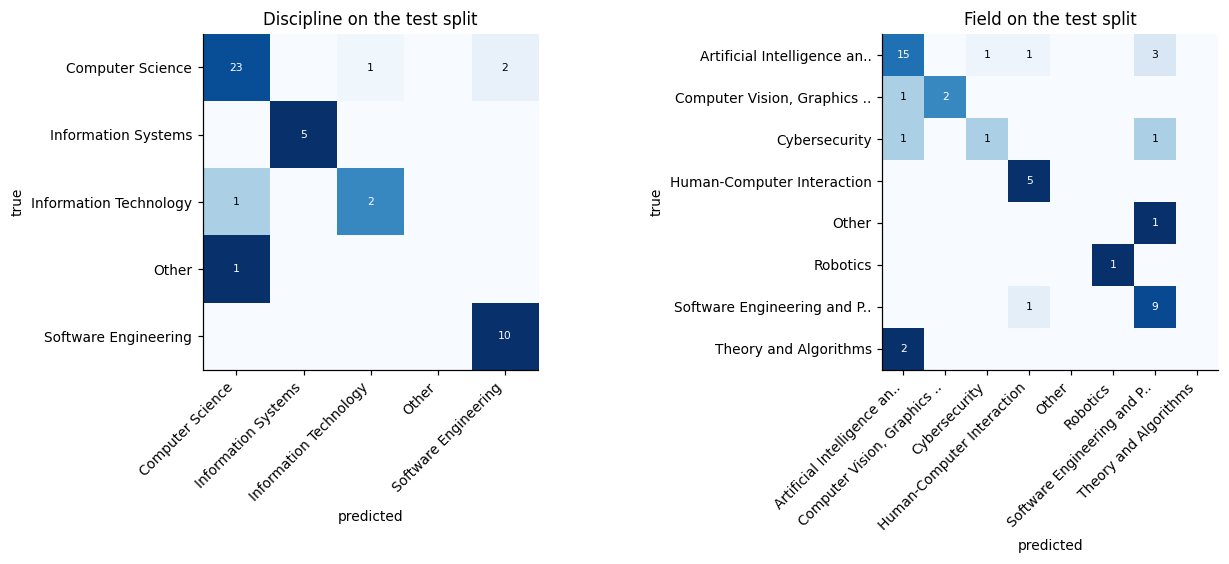

In [44]:
test_rows = []
backends = {"classical": CLASSICAL["test"], **({"SciBERT": SCIBERT["test"]} if SCIBERT else {})}
for task in ["discipline", "field"]:
    for backend, predictions in backends.items():
        scores = single_label_scores(papers.loc[TEST, task], predictions[task])
        test_rows.append({"task": task, "backend": backend, **scores})
        for metric, value in scores.items():
            record_result("16", task, backend, "test", metric, value)
display(pd.DataFrame(test_rows).set_index(["task", "backend"]).round(3))

final_test = {task: (SCIBERT if FINAL_BACKEND[task] == "scibert" else CLASSICAL)["test"][task] for task in ["discipline", "field"]}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1, 1.7]})
for ax, task in zip(axes, ["discipline", "field"]):
    labels = sorted(set(papers.loc[TEST, task]) | set(final_test[task]))
    plot_confusion(papers.loc[TEST, task].values, final_test[task], labels, f"{task.title()} on the test split", ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_test.png", bbox_inches="tight")
plt.show()

### 16.1 Significance Testing

With a test set this small, a gap of a few points between two models could be down to chance. McNemar's exact test looks only at the papers where exactly one of the two models is correct. If both models were equally good, those disagreements would split 50/50, so the test asks how likely the observed split would be under that assumption.

In [45]:
def mcnemar_exact(correct_a, correct_b):
    only_a = int(np.sum(correct_a & ~correct_b))
    only_b = int(np.sum(~correct_a & correct_b))
    p_value = binomtest(min(only_a, only_b), only_a + only_b, 0.5).pvalue if only_a + only_b else 1.0
    return only_a, only_b, p_value


if SCIBERT:
    for task in ["discipline", "field"]:
        truth = papers.loc[TEST, task].values
        classical_correct = np.array(CLASSICAL["test"][task]) == truth
        scibert_correct = np.array(SCIBERT["test"][task]) == truth
        only_classical, only_scibert, p_value = mcnemar_exact(classical_correct, scibert_correct)
        print(f"{task}: only classical correct {only_classical}, only SciBERT correct {only_scibert}, "
              f"exact McNemar p = {p_value:.3f} ({'significant' if p_value < 0.05 else 'not significant'} at 0.05)")
        record_result("16.1", task, "classical vs SciBERT", "test", "McNemar p-value", p_value)
else:
    print("SciBERT was not run, so there is no second model to compare against")

discipline: only classical correct 1, only SciBERT correct 5, exact McNemar p = 0.219 (not significant at 0.05)
field: only classical correct 3, only SciBERT correct 6, exact McNemar p = 0.508 (not significant at 0.05)


### 16.2 Methodology on the Test Split

The ROC curves use the SVM's decision scores for each learned strategy. The reference labels are the human labels from Section 8.1 when they are available, and the rule labels otherwise, as stated in the chart title. SciBERT's methodology head is scored on the same papers for comparison.

,micro F1,macro F1,exact match
model,,,
SVM + rules (hybrid),0.785,0.427,0.467
SciBERT,0.791,0.417,0.400


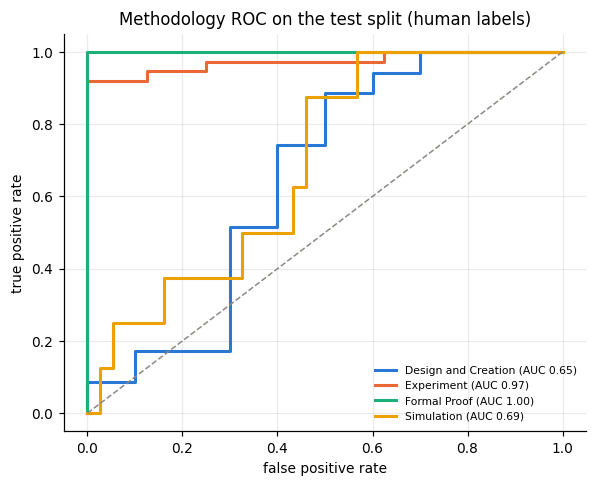

In [46]:
reference = Y_human.loc[Y_human.index.intersection(TEST)] if HAS_HUMAN_LABELS else Y_rules.loc[TEST]
reference_name = "human labels" if HAS_HUMAN_LABELS else "rule labels"
ref_ids = list(reference.index)

rows = [{"model": "SVM + rules (hybrid)", **multilabel_scores(reference.values, CLASSICAL["test"]["methodology"].loc[ref_ids].values)}]
if SCIBERT_PROBS:
    scibert_method = pd.DataFrame((SCIBERT_PROBS["test"]["methodology"] > 0.5).astype(int), index=TEST, columns=STRATEGIES)
    rows.append({"model": "SciBERT", **multilabel_scores(reference.values, scibert_method.loc[ref_ids].values)})
for row in rows:
    for metric in ["micro F1", "macro F1", "exact match"]:
        record_result("16.2", "methodology", row["model"], f"test vs {reference_name}", metric, row[metric])
display(pd.DataFrame(rows).set_index("model").round(3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
palette = [BLUE, ORANGE, "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
for colour, strategy in zip(palette, TRAINABLE):
    y_true = reference[strategy].values
    if 0 < y_true.sum() < len(y_true):
        scores = CLASSICAL["test"]["method_scores"].loc[ref_ids, strategy].values
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        ax.plot(fpr, tpr, color=colour, lw=2, label=f"{strategy} (AUC {auc:.2f})")
        record_result("16.2", "methodology", "Linear SVM", f"test vs {reference_name}", f"ROC AUC {strategy}", auc)
ax.plot([0, 1], [0, 1], color=GREY, lw=1, ls="--")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title(f"Methodology ROC on the test split ({reference_name})")
ax.legend(frameon=False, fontsize=7, loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "methodology_roc.png", bbox_inches="tight")
plt.show()

### 16.3 Error Analysis

As the design chapter planned, the errors examined are the confident ones: papers where the final field classifier was confidently wrong. These usually point to either an ambiguous paper sitting between fields, or a limitation in how arXiv categories map to fields, rather than to random noise.

In [47]:
final_field_source = (SCIBERT if FINAL_BACKEND["field"] == "scibert" else CLASSICAL)["test"]
errors = pd.DataFrame({"title": papers.loc[TEST, "title"].str[:70], "arXiv category": papers.loc[TEST, "category"],
                       "true field": papers.loc[TEST, "field"], "predicted field": final_field_source["field"],
                       "confidence": final_field_source["field_conf"]}, index=TEST)
errors = errors[errors["true field"] != errors["predicted field"]].sort_values("confidence", ascending=False)
print(f"{len(errors)} field errors out of {len(TEST)} test papers")
errors.head(8).round(3)

12 field errors out of 45 test papers


,title,arXiv category,true field,predicted field,confidence
arxiv_2608.17374v1,On the Pseudo-Mixing of Kac’s Walk,math.PR,Theory and Algorithms,Artificial Intelligence and Machine Learning,0.231
arxiv_2608.17147v1,Picture the Epsilon: Pursuing Identity-Level Privacy Guarantees for Im,cs.CR,Cybersecurity,Artificial Intelligence and Machine Learning,0.173
arxiv_2608.17248v1,I NFORMATION FUSION AND MACHINE LEARNING FOR,cs.CE,Theory and Algorithms,Artificial Intelligence and Machine Learning,0.153
arxiv_2608.17993v1,What Does It Mean and Why Should I Bother? Motivating Students to Writ,cs.SE,Software Engineering and Programming Languages,Human-Computer Interaction,0.144
arxiv_2608.13612v1,SemPlan: Benchmarking Structured Semantic Planning for LLM-Based Queri,cs.AI,Artificial Intelligence and Machine Learning,Software Engineering and Programming Languages,0.132
arxiv_2608.18055v1,Primitive Representation Learning for Unsupervised Dynamic Contrast En,eess.IV,"Computer Vision, Graphics and Multimedia",Artificial Intelligence and Machine Learning,0.127
arxiv_2608.17800v1,StartupBench: Benchmarking General-Purpose Agents on Market-Validated,cs.AI,Artificial Intelligence and Machine Learning,Software Engineering and Programming Languages,0.126
arxiv_2608.13928v1,CoSA: Context-Aware Severity Assessment via Context Analysis with Larg,cs.CR,Cybersecurity,Software Engineering and Programming Languages,0.125


## 17. Final Pipeline

The function below is the finished system. It takes one PDF and runs every stage: layout-aware extraction, segmentation, the context-aware annotator, the discipline and field classifiers (on whichever backend won validation, combined through the chosen hierarchy strategy), and the hybrid methodology classifier. The result is a structured JSON record, with each methodology label carrying its supporting sentences, so a reader can check any decision against the paper itself.

In [48]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def ranked(scores, labels, n=3):
    probabilities = softmax(scores)[0]
    order = np.argsort(probabilities)[::-1][:n]
    return [{"label": labels[i], "confidence": round(float(probabilities[i]), 3)} for i in order]


def classify_publication(pdf_path, models):
    record = extract_pdf(Path(pdf_path))
    segment = segment_document(record)
    annotation = annotate(segment)
    texts = {view: pd.Series([view_text(segment, view)], index=["doc"]) for view in VIEW_ZONES}

    disc_scores = classifier_scores(models["discipline"], texts["full text"], DISCIPLINE_LABELS)
    field_scores = classifier_scores(models["field"], texts["full text"], FIELD_LABELS)
    if RUN_SCIBERT and "scibert" in FINAL_BACKEND.values():
        probs = run_model(scibert, ["doc"], {"doc": encode(scibert_text(segment))})
        if FINAL_BACKEND["discipline"] == "scibert":
            disc_scores = np.log(probs["discipline"] + 1e-9)
        if FINAL_BACKEND["field"] == "scibert":
            field_scores = np.log(probs["field"] + 1e-9)
    discipline, field = resolve_hierarchy(disc_scores, field_scores)
    method_scores = methodology_scores(models["methodology"], texts[METHOD_VIEW]).iloc[0]

    strategies = []
    for strategy in STRATEGIES:
        rule = annotation["strategies"][strategy]
        model_says = strategy in TRAINABLE and method_scores[strategy] > HYBRID_MARGIN
        if not (rule["present"] or model_says):
            continue
        model_confidence = float(sigmoid(method_scores[strategy])) if strategy in TRAINABLE else 0.0
        decided_by = "rules and model" if rule["present"] and model_says else "rules" if rule["present"] else "model only (no applied evidence found)"
        strategies.append({"strategy": strategy, "confidence": round(max(rule["confidence"], model_confidence), 3),
                           "decided_by": decided_by,
                           "evidence": [{"section": e["zone"], "sentence": e["sentence"]} for e in rule["evidence"][:2]],
                           "mentions_in_related_work_or_citations": rule["mentions"]})
    strategies.sort(key=lambda s: -s["confidence"])

    return {
        "file": Path(pdf_path).name,
        "title": segment["title"],
        "arxiv_category_on_pdf": record["stamp"]["category"] if record["stamp"] else None,
        "discipline": {"label": discipline[0], "alternatives": ranked(disc_scores, DISCIPLINE_LABELS)},
        "field": {"label": field[0], "alternatives": ranked(field_scores, FIELD_LABELS)},
        "research_strategies": strategies,
        "data_generation_methods": [{"method": g, "evidence": r["evidence"][0]["sentence"] if r["evidence"] else ""}
                                    for g, r in annotation["generation"].items() if r["present"]],
        "data_analysis_approach": annotation["approach"],
        "document_structure": {"pages": record["n_pages"], "two_column_pages": record["two_column_pages"],
                               "sections": [h for _, h in segment["headings"]], "segmentation": segment["method"]},
    }

The demonstration uses the models trained on the training split only, so the test papers below are unseen and their output shows real behaviour. The printed record is the full output for one paper.

In [49]:
EVAL_MODELS = {"discipline": eval_discipline, "field": eval_field, "methodology": eval_method}
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"
PREDICTIONS_DIR.mkdir(exist_ok=True)

demo_rows = []
for doc_id in TEST:
    result = classify_publication(DATA_DIR / extracted[doc_id]["file"], EVAL_MODELS)
    (PREDICTIONS_DIR / f"{doc_id}.json").write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
    demo_rows.append({"doc": doc_id, "title": result["title"][:60], "true field": papers.loc[doc_id, "field"],
                      "predicted field": result["field"]["label"], "predicted discipline": result["discipline"]["label"],
                      "strategies": ", ".join(s["strategy"] for s in result["research_strategies"]),
                      "analysis": result["data_analysis_approach"]})
demo = pd.DataFrame(demo_rows).set_index("doc")
demo.to_csv(OUTPUT_DIR / "test_split_predictions.csv", encoding="utf-8-sig")
print(f"wrote {len(demo)} JSON records to {PREDICTIONS_DIR}")
print(json.dumps(json.loads((PREDICTIONS_DIR / f"{TEST[0]}.json").read_text(encoding="utf-8")), indent=2, ensure_ascii=False)[:3500])

wrote 45 JSON records to outputs\predictions
{
  "file": "arxiv_2608.12859v1.pdf",
  "title": "Dissecting Software Graphs: Structural Insights for Driver-Guided Fuzzing",
  "arxiv_category_on_pdf": "cs.SE",
  "discipline": {
    "label": "Software Engineering",
    "alternatives": [
      {
        "label": "Software Engineering",
        "confidence": 1.0
      },
      {
        "label": "Information Technology",
        "confidence": 0.0
      },
      {
        "label": "Other",
        "confidence": 0.0
      }
    ]
  },
  "field": {
    "label": "Software Engineering and Programming Languages",
    "alternatives": [
      {
        "label": "Software Engineering and Programming Languages",
        "confidence": 0.152
      },
      {
        "label": "Artificial Intelligence and Machine Learning",
        "confidence": 0.098
      },
      {
        "label": "Other",
        "confidence": 0.08
      }
    ]
  },
  "research_strategies": [
    {
      "strategy": "Experiment",
  

In [50]:
demo.head(15)

,title,true field,predicted field,predicted discipline,strategies,analysis
doc,,,,,,
arxiv_2608.12859v1,Dissecting Software Graphs: Structural Insights for Driver-G,Software Engineering and Programming Languages,Software Engineering and Programming Languages,Software Engineering,"Experiment, Design and Creation",Quantitative
arxiv_2608.13240v1,Can Formal Specifications Be Synthesized from Tests Alone?,Software Engineering and Programming Languages,Software Engineering and Programming Languages,Software Engineering,Design and Creation,Quantitative
arxiv_2608.13612v1,SemPlan: Benchmarking Structured Semantic Planning for LLM-B,Artificial Intelligence and Machine Learning,Software Engineering and Programming Languages,Software Engineering,Experiment,Quantitative
arxiv_2608.13928v1,CoSA: Context-Aware Severity Assessment via Context Analysis,Cybersecurity,Software Engineering and Programming Languages,Software Engineering,"Experiment, Design and Creation",Quantitative
arxiv_2608.14742v1,PandasCorpus: A Resource of Real-World Pandas Workflows and,Software Engineering and Programming Languages,Software Engineering and Programming Languages,Software Engineering,Design and Creation,Quantitative
arxiv_2608.15412v1,Invariant Pretraining for Robust Code Representations,Artificial Intelligence and Machine Learning,Artificial Intelligence and Machine Learning,Computer Science,"Experiment, Design and Creation",Quantitative
arxiv_2608.15579v1,Kozuchi Agent: A Language-Agnostic Open-Weight Agent for Sof,Software Engineering and Programming Languages,Software Engineering and Programming Languages,Software Engineering,"Experiment, Design and Creation",Quantitative
arxiv_2608.16022v1,O PEN H ARMONY B ENCH : E VALUATING LLM S AND C ODING A GENT,Software Engineering and Programming Languages,Software Engineering and Programming Languages,Software Engineering,Design and Creation,Quantitative
arxiv_2608.16293v1,Principled Authority Switching for Shared Autonomy in Human-,Human-Computer Interaction,Human-Computer Interaction,Information Systems,"Formal Proof, Experiment, Design and Creation",Quantitative


### 17.1 Classifying New Publications

For real use, the classical models are refitted on all 300 papers and saved to the models folder. Any PDF placed in the new_papers folder is classified when the cell runs, and the results are written to outputs/new_papers_predictions.jsonl. It does not have to be an arXiv paper. When a PDF has no arXiv stamp, the discipline and field are predicted from the text alone, which is the case the system was built for.

In [51]:
import joblib

ALL_IDS = list(papers.index)
DEPLOYED = {"discipline": fit_classifier("discipline", ALL_IDS), "field": fit_classifier("field", ALL_IDS),
            "methodology": fit_methodology_model(ALL_IDS)}
joblib.dump(DEPLOYED, MODEL_DIR / "classical_models.joblib")

new_pdfs = sorted(NEW_PAPERS_DIR.glob("*.pdf"))
if new_pdfs:
    with open(OUTPUT_DIR / "new_papers_predictions.jsonl", "w", encoding="utf-8") as handle:
        for pdf in new_pdfs:
            result = classify_publication(pdf, DEPLOYED)
            handle.write(json.dumps(result, ensure_ascii=False) + "\n")
            print(f"{pdf.name}: {result['discipline']['label']} > {result['field']['label']} | "
                  f"{', '.join(s['strategy'] for s in result['research_strategies']) or 'no strategy identified'}")
else:
    print(f"no PDFs in {NEW_PAPERS_DIR}, add some and re-run this cell")

2609.28475v1.pdf: Computer Science > Artificial Intelligence and Machine Learning | Experiment
2609.28506v1.pdf: Computer Science > Artificial Intelligence and Machine Learning | no strategy identified
2609.28547v1.pdf: Information Systems > Human-Computer Interaction | Simulation
2609.28554v1.pdf: Computer Science > Artificial Intelligence and Machine Learning | Experiment, Design and Creation
2609.28570v1.pdf: Computer Science > Artificial Intelligence and Machine Learning | Experiment, Formal Proof


### 17.2 Corpus Analytics

Applied to a whole collection, the pipeline answers the meta-research question behind the project brief: how is research conducted in each computing discipline? The heatmaps show, for each discipline, the share of papers using each strategy and each data generation method. They are built from the arXiv discipline labels and the context-aware annotations of all 300 papers.

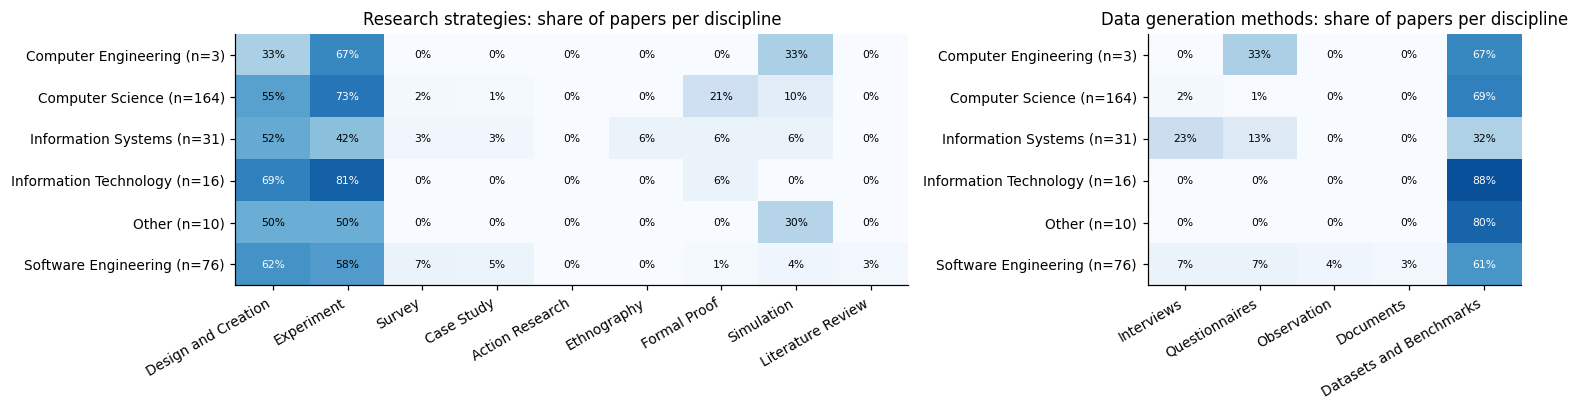

approach,Mixed methods,Not determined,Qualitative,Quantitative
discipline,,,,
Computer Engineering,0.0,0.0,0.0,100.0
Computer Science,5.0,7.0,0.0,87.0
Information Systems,26.0,29.0,16.0,29.0
Information Technology,0.0,19.0,0.0,81.0
Other,10.0,10.0,0.0,80.0
Software Engineering,5.0,26.0,1.0,67.0


In [52]:
profile = pd.concat([papers[["discipline", "field", "approach"]], Y_rules], axis=1)
generation = pd.DataFrame([[int(annotations[d]["generation"][g]["present"]) for g in DATA_GENERATION] for d in papers.index],
                          index=papers.index, columns=DATA_GENERATION)
profile = pd.concat([profile, generation], axis=1)
profile.to_csv(OUTPUT_DIR / "corpus_methodology_profile.csv", encoding="utf-8-sig")

by_discipline = profile.groupby("discipline")
counts = by_discipline.size()
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [9, 5]})
for ax, columns, title in [(axes[0], STRATEGIES, "Research strategies"), (axes[1], DATA_GENERATION, "Data generation methods")]:
    shares = by_discipline[columns].mean()
    ax.imshow(shares.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(columns)), columns, rotation=30, ha="right")
    ax.set_yticks(range(len(shares)), [f"{d} (n={counts[d]})" for d in shares.index])
    for i in range(shares.shape[0]):
        for j in range(shares.shape[1]):
            ax.text(j, i, f"{shares.values[i, j]:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if shares.values[i, j] > 0.6 else "black")
    ax.set_title(f"{title}: share of papers per discipline")
    ax.grid(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "methodology_by_discipline.png", bbox_inches="tight")
plt.show()
(pd.crosstab(profile["discipline"], profile["approach"], normalize="index") * 100).round(0)

## 18. Evaluation Summary

Every number reported above was logged as it was computed. The full log is saved to outputs/evaluation_summary.csv so the report's evaluation chapter can quote results exactly. The tables below group the headline results by the kind of task, so each table only has the metrics that apply to it.

In [53]:
summary = pd.DataFrame(EVAL_ROWS)
summary.to_csv(OUTPUT_DIR / "evaluation_summary.csv", index=False, encoding="utf-8-sig")


def summary_table(tasks, metrics, sections):
    rows = summary[summary["task"].isin(tasks) & summary["metric"].isin(metrics) & summary["section"].isin(sections)]
    return rows.pivot_table(index=["section", "task", "model", "split"], columns="metric", values="value",
                            aggfunc="first", sort=False)[metrics].round(3)


print("discipline and field classification")
display(summary_table(["discipline", "field"], ["accuracy", "macro F1"], ["10", "16"]))
print("methodology classification")
display(summary_table(["methodology"], ["micro F1", "macro F1"], ["13", "16.2"]))
print("agreement and significance")
display(summary[summary["metric"].isin(["cohen kappa", "McNemar p-value"])]
        .set_index(["section", "task", "model", "split", "metric"])["value"].round(3).to_frame())

discipline and field classification


metric                                                   accuracy  macro F1
section task       model                  split                            
10      discipline Majority class         dev 5-fold CV     0.541     0.117
                   Complement Naive Bayes dev 5-fold CV     0.792     0.405
                   Logistic Regression    dev 5-fold CV     0.804     0.413
                   Linear SVM             dev 5-fold CV     0.808     0.415
        field      Majority class         dev 5-fold CV     0.424     0.046
                   Complement Naive Bayes dev 5-fold CV     0.694     0.216
                   Logistic Regression    dev 5-fold CV     0.710     0.258
                   Linear SVM             dev 5-fold CV     0.718     0.277
16      discipline classical              test              0.800     0.572
                   SciBERT                test              0.889     0.696
        field      classical              test              0.733     0.569
                   SciBERT                test              0.800     0.594

methodology classification


metric                                                                         micro F1  macro F1
section task        model                        split                                           
13      methodology Linear SVM                   dev 5-fold CV vs rule labels     0.782     0.597
                    Logistic Regression          dev 5-fold CV vs rule labels     0.783     0.594
                    Naive keyword matching       test vs human labels             0.778     0.473
                    Context-aware rules          test vs human labels             0.775     0.424
                    SVM (trained on rule labels) test vs human labels             0.783     0.348
                    Hybrid (final pipeline)      test vs human labels             0.780     0.425
16.2    methodology SVM + rules (hybrid)         test vs human labels             0.785     0.427
                    SciBERT                      test vs human labels             0.791     0.417

agreement and significance


value
section task        model                         split metric                
8.1     methodology annotator 1 vs annotator 2    test  cohen kappa      0.980
                    rule annotator vs annotator 1 test  cohen kappa      0.721
16.1    discipline  classical vs SciBERT          test  McNemar p-value  0.219
        field       classical vs SciBERT          test  McNemar p-value  0.508

### Limitations

- **Methodology training labels come from rules.** The learned methodology models are trained on the rule labels, so they inherit the rules' blind spots. The human labels in Section 8.1 turn agreement with the rules into an accuracy estimate, so the results against human labels are the ones to report for the methodology tier.
- **The human-labelled test set is small.** 45 papers are enough for overall scores, but rare strategies have only a handful of positive examples (or none), so their per-strategy scores are unstable and should be read with care.
- **arXiv categories are the authors' own choice.** A paper sitting between fields may be filed under either one. The mapping from categories to CC2020 disciplines is also a documented design decision rather than an official crosswalk. Some confident errors in Section 16.3 are this kind of disagreement rather than model failure.
- **The corpus reflects arXiv.** Information Systems and Information Technology research is under-represented compared with ACM and IEEE venues, and qualitative strategies such as action research and ethnography are rare, which is why they are handled by rules alone.
- **Extraction is heuristic.** Tables, equations and unusual templates can still produce broken sentences. Heading detection falls back to a fixed window when no structure is found, and Section 6 reports how often that happened.
- **Confidence scores are not calibrated probabilities.** SVM scores are passed through softmax or sigmoid functions, which ranks predictions sensibly, but a stated 0.8 should not be read as an 80% chance of being correct.